# TiRex-2 Coupling on Real Time Series

`CouplingPipeline.generate` always draws a **synthetic GP** univariate pool.
The paper's pre-training protocol is broader: Appendix E samples univariate series from a mixed corpus (Chronos real data $\sim$ 30M, GP synthetics $\sim$ 15M, GIFT-Eval $\sim$ 2.5M), z-score normalises them, then passes the batch through the same coupling mechanisms.

<p align="center">
<img width="80%" align="middle" src="../../docs/source/_static/TiRex-2.jpg">
</p>

This notebook uses the **existing-series entry** `CouplingPipeline.__call__(rng, series)` on bundled 4096-step slices of public forecasting datasets, and measures how coupling **changes cross-channel correlation**.

Two protocols:

1. **Within-dataset mixing** — different numeric channels of the same file (ETTh1).
2. **Cross-dataset mixing** — `OT` channels from ETT / exchange / weather / electricity, stacked as independent univariate inputs (the paper's "draw $V$ series from a shared pool").

Post-processing is turned **off** so NaNs and channel permutation do not confound the correlation diagnostics. Series are z-scored per channel before coupling, matching Appendix E.


## Bundled slices

`s2generator.utils.data` ships 4096-step excerpts with the package:

| Name | File | Univariate (`load_univariate`) | Multivariate (`load_multivariate`) |
| --- | --- | --- | --- |
| `ETTh1`, `ETTh2`, `ETTm1`, `ETTm2` | CSV | `OT` column | full table incl. `date` |
| `exchange_rate`, `weather` | CSV | `OT` column | full table incl. `date` |
| `electricity` | `.npy` | OT array | not available |

**Shape reminder.** `__call__` consumes and returns `(T, Q)`. Plots use `.T` → `(Q, T)`.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import CouplingPipeline
from s2generator.utils import (
    load_univariate,
    load_multivariate,
    list_datasets,
    z_score_normalization,
    plot_univariate_time_series,
    plot_multivariate_time_series,
    plot_correlation,
    multivariate_correlation,
)


def channels(series: np.ndarray) -> np.ndarray:
    return np.asarray(series).T


def mean_offdiag_pearson(series_tq: np.ndarray) -> float:
    corr = multivariate_correlation(channels(series_tq), measure="pearson")
    mask = ~np.eye(corr.shape[0], dtype=bool)
    return float(np.mean(np.abs(corr[mask])))


def show_series(series_tq: np.ndarray, title: str) -> None:
    print(title)
    print("  shape (T, Q):", series_tq.shape)
    print("  mean |Pearson| off-diagonal:", f"{mean_offdiag_pearson(series_tq):.3f}")
    fig = plot_multivariate_time_series(channels(series_tq))
    fig.axes[0].set_title(title, fontweight="bold", fontsize=12)
    fig = plot_correlation(channels(series_tq), measure="pearson spearman")
    plt.show()


pipe = CouplingPipeline()
rng = np.random.RandomState(0)
print("univariate datasets:", list_datasets("univariate"))
print("multivariate datasets:", list_datasets("multivariate"))

univariate datasets: ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'exchange_rate', 'weather', 'electricity']
multivariate datasets: ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'exchange_rate', 'weather']


## Inspect the OT targets

Each CSV slice exposes an `OT` column; electricity is stored directly as a length-4096 array.


ETTh1             shape=(4096,)  mean=  22.389  std=   9.676
ETTh2             shape=(4096,)  mean=  31.214  std=  11.411
ETTm1             shape=(4096,)  mean=  33.759  std=   5.203
ETTm2             shape=(4096,)  mean=  41.542  std=   6.803
exchange_rate     shape=(4096,)  mean=   0.580  std=   0.088
weather           shape=(4096,)  mean= 432.551  std=  11.762
electricity       shape=(4096,)  mean=3296.979  std= 367.892


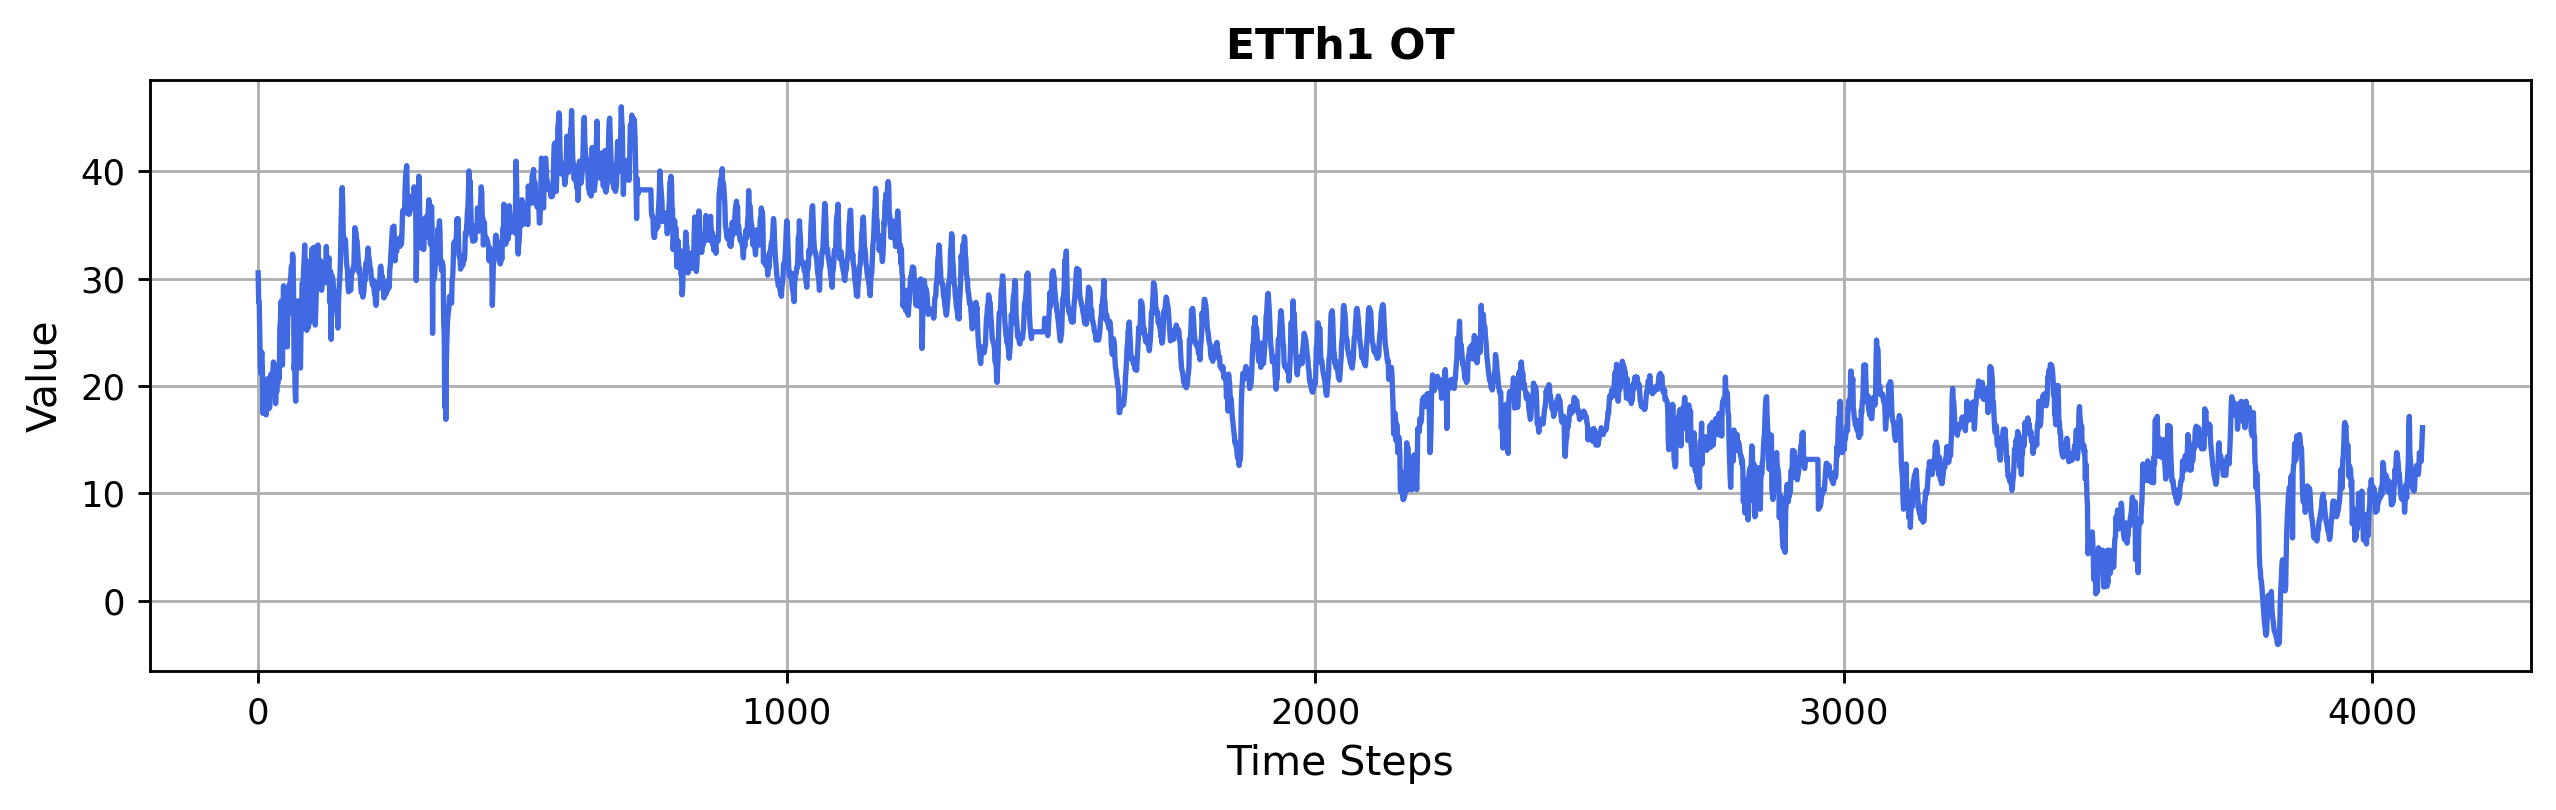

In [2]:
ot_names = [
    "ETTh1",
    "ETTh2",
    "ETTm1",
    "ETTm2",
    "exchange_rate",
    "weather",
    "electricity",
]
for name in ot_names:
    series = load_univariate(name)
    print(
        f"{name:16s}  shape={series.shape}  mean={series.mean():8.3f}  std={series.std():8.3f}"
    )

fig = plot_univariate_time_series(load_univariate("ETTh1"))
fig.axes[0].set_title("ETTh1 OT", fontweight="bold")
plt.show()

## Experiment 1 — same dataset, different channels

Load ETTh1, drop `date`, and treat the seven numeric sensors (`HUFL`, `HULL`, `MUFL`, `MULL`, `LUFL`, `LULL`, `OT`) as the univariate pool $z_1,\ldots,z_7$.
This tests whether coupling can **re-mix physically related channels of one system**.

`identity` is the control (correlation should match the raw z-scored series).
`linear_mixing` and `functional` should raise dependence;
`linear_scm` injects lagged directed structure;
`cointegration` **ignores** $z$ and is shown only as a negative control.


ETTh1 channels: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
channel index map:
  0: HUFL
  1: HULL
  2: MUFL
  3: MULL
  4: LUFL
  5: LULL
  6: OT
ETTh1 channels (z-scored, before coupling)
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.451


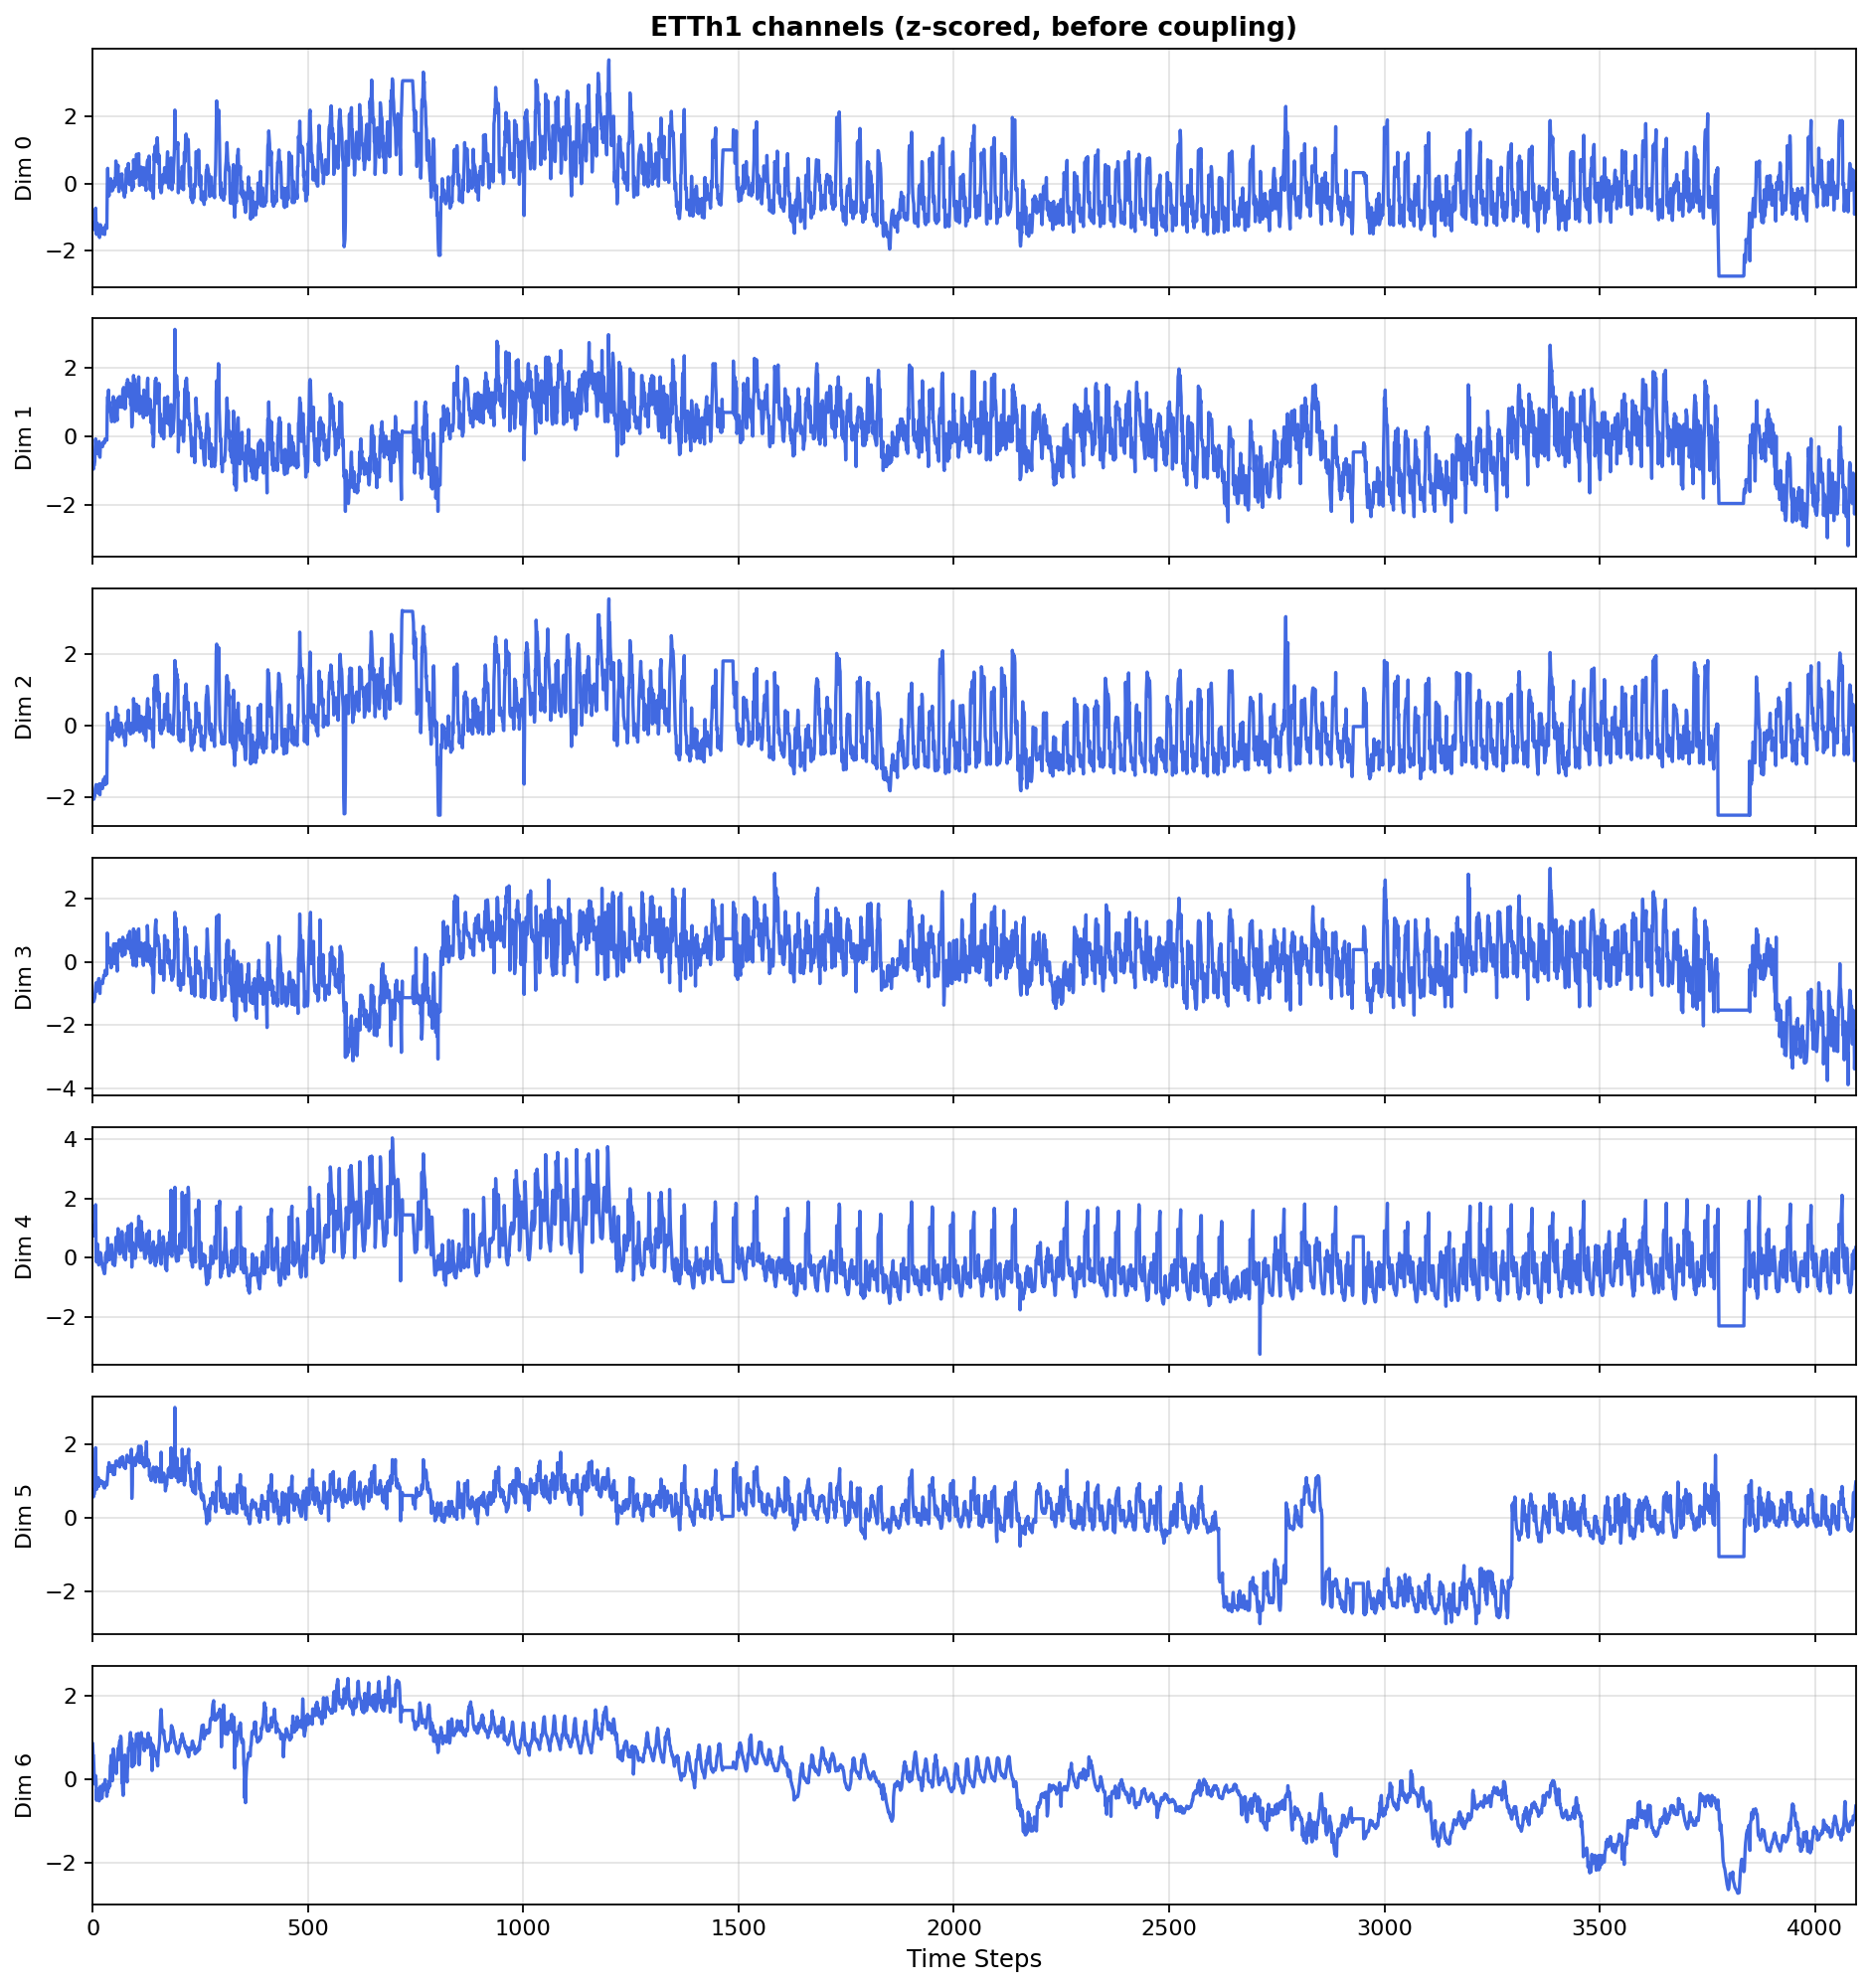

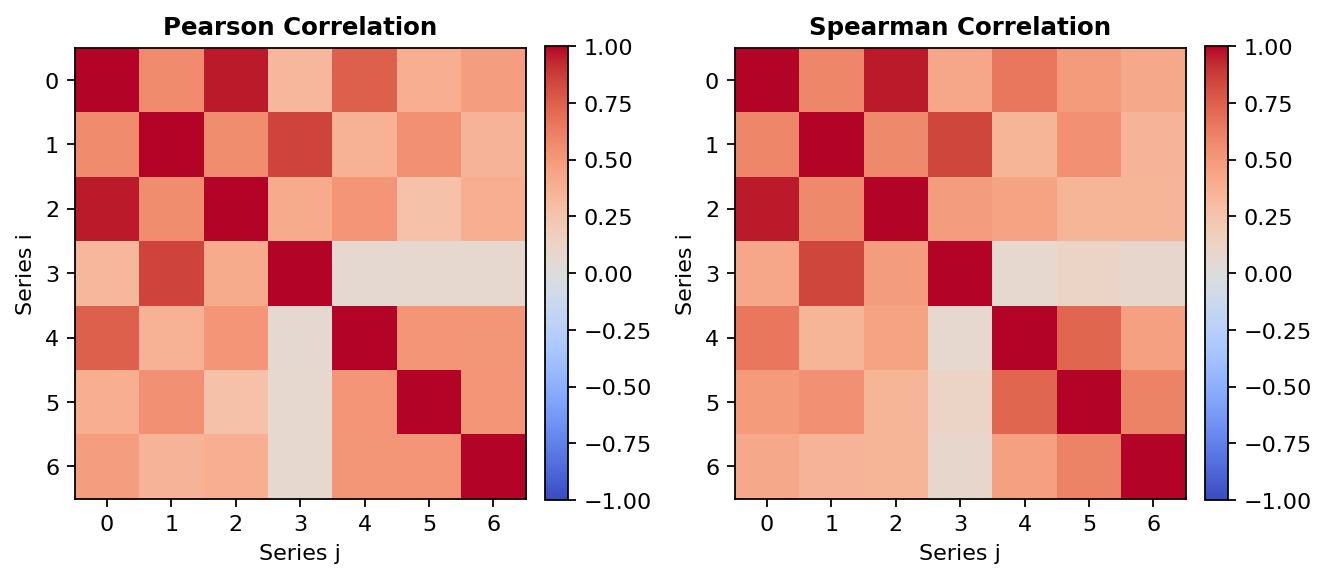

In [3]:
ett = load_multivariate("ETTh1")
numeric_cols = [c for c in ett.columns if c != "date"]
print("ETTh1 channels:", numeric_cols)

raw = ett[numeric_cols].to_numpy(dtype=np.float64)  # (T, Q)
z = z_score_normalization(raw)
assert z is not None
print("channel index map:")
for i, col in enumerate(numeric_cols):
    print(f"  {i}: {col}")

show_series(z, "ETTh1 channels (z-scored, before coupling)")

ETTh1 after identity
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.451


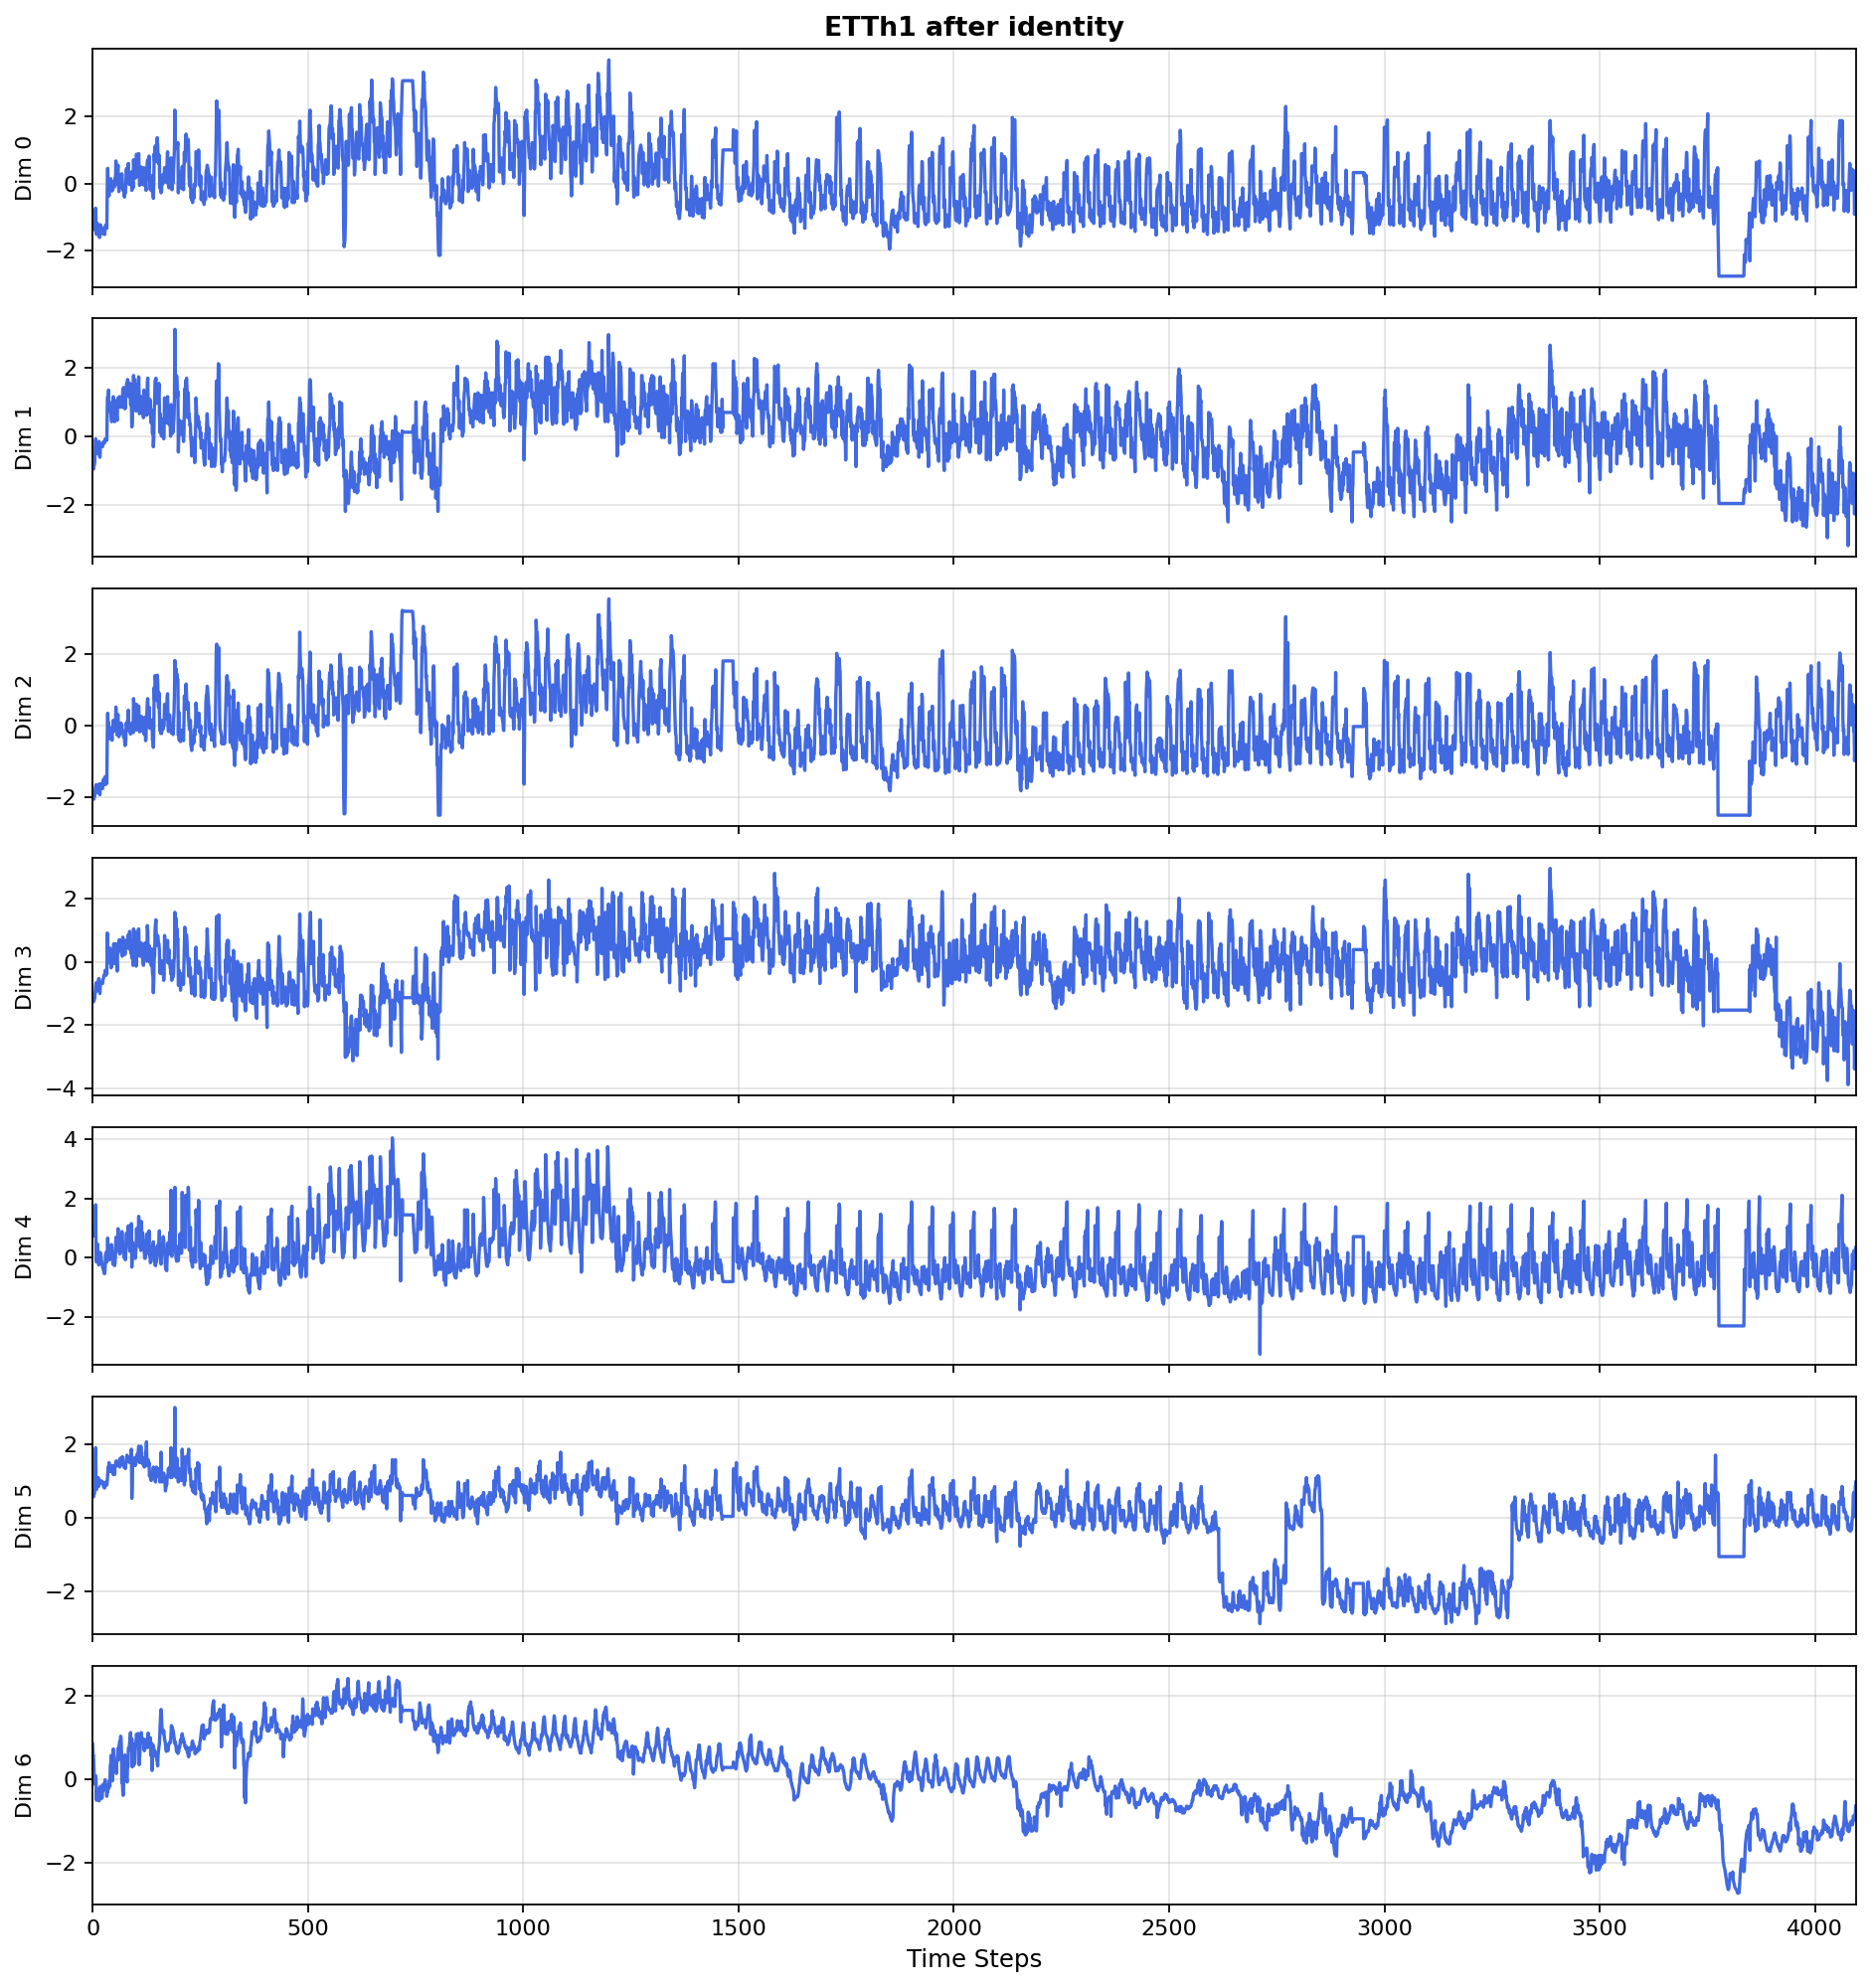

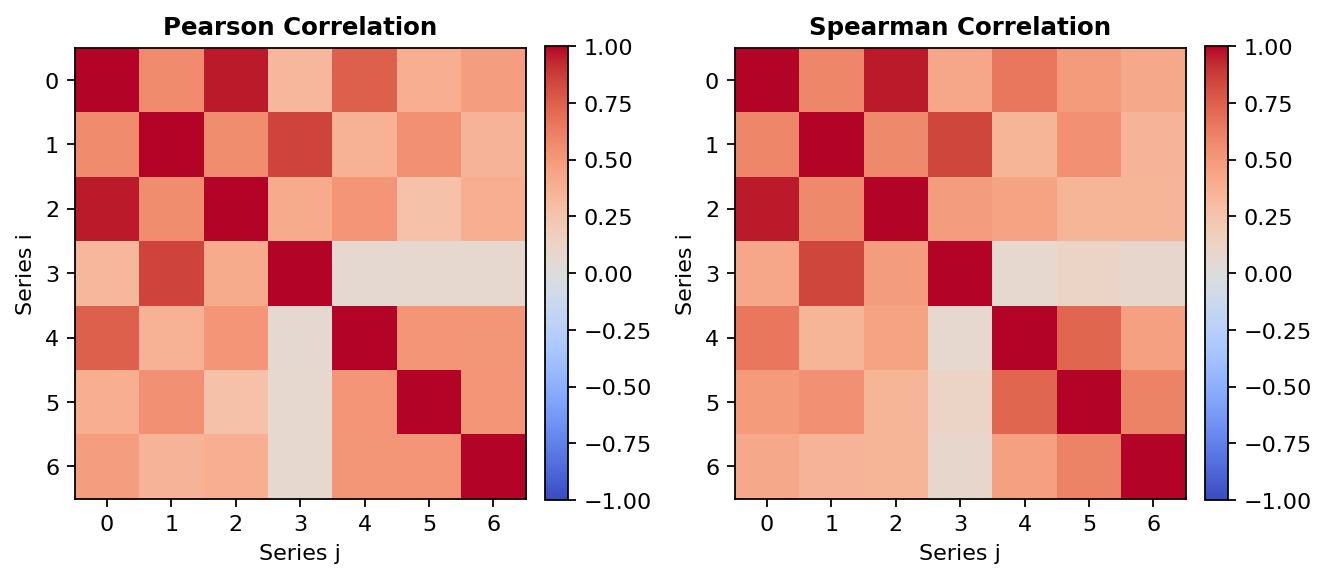

ETTh1 after linear_mixing
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.399


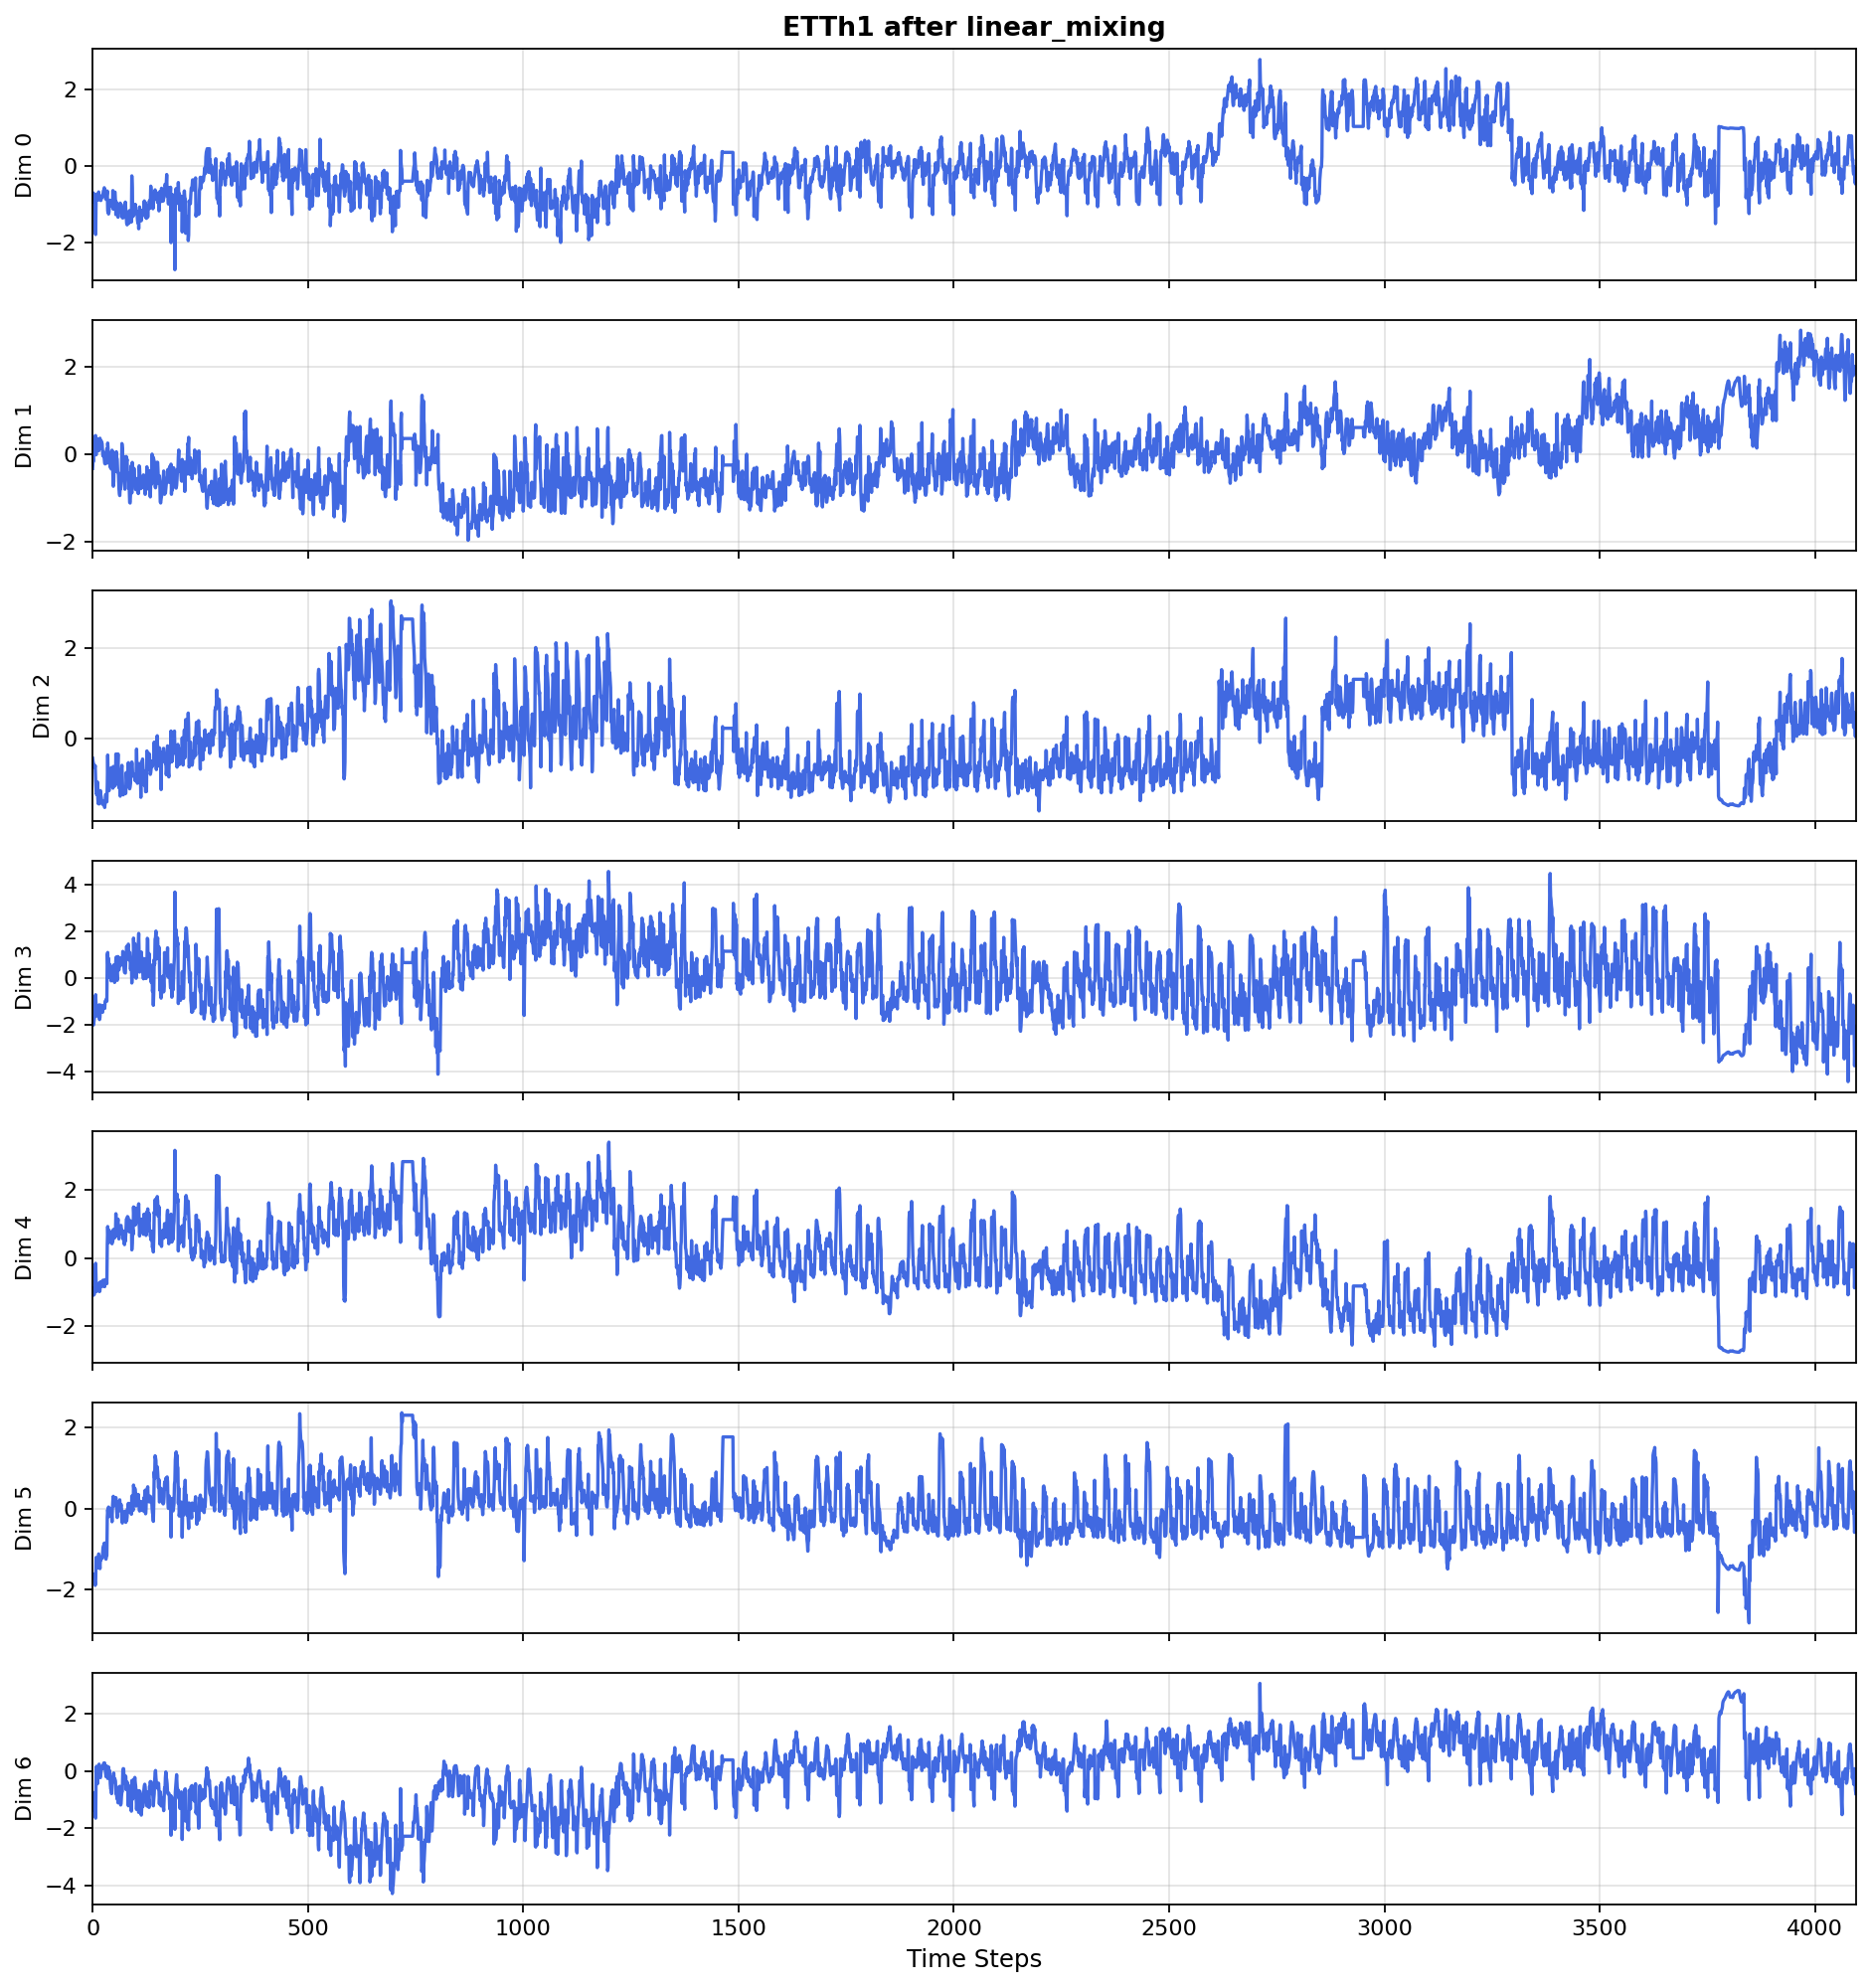

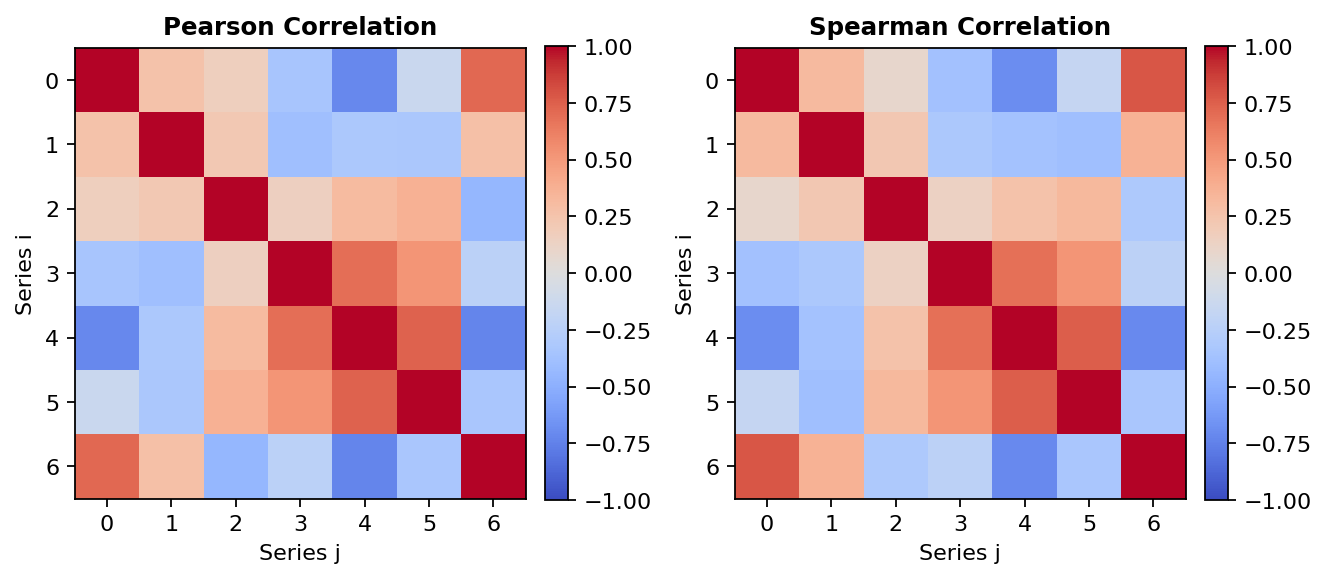

ETTh1 after functional
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.827


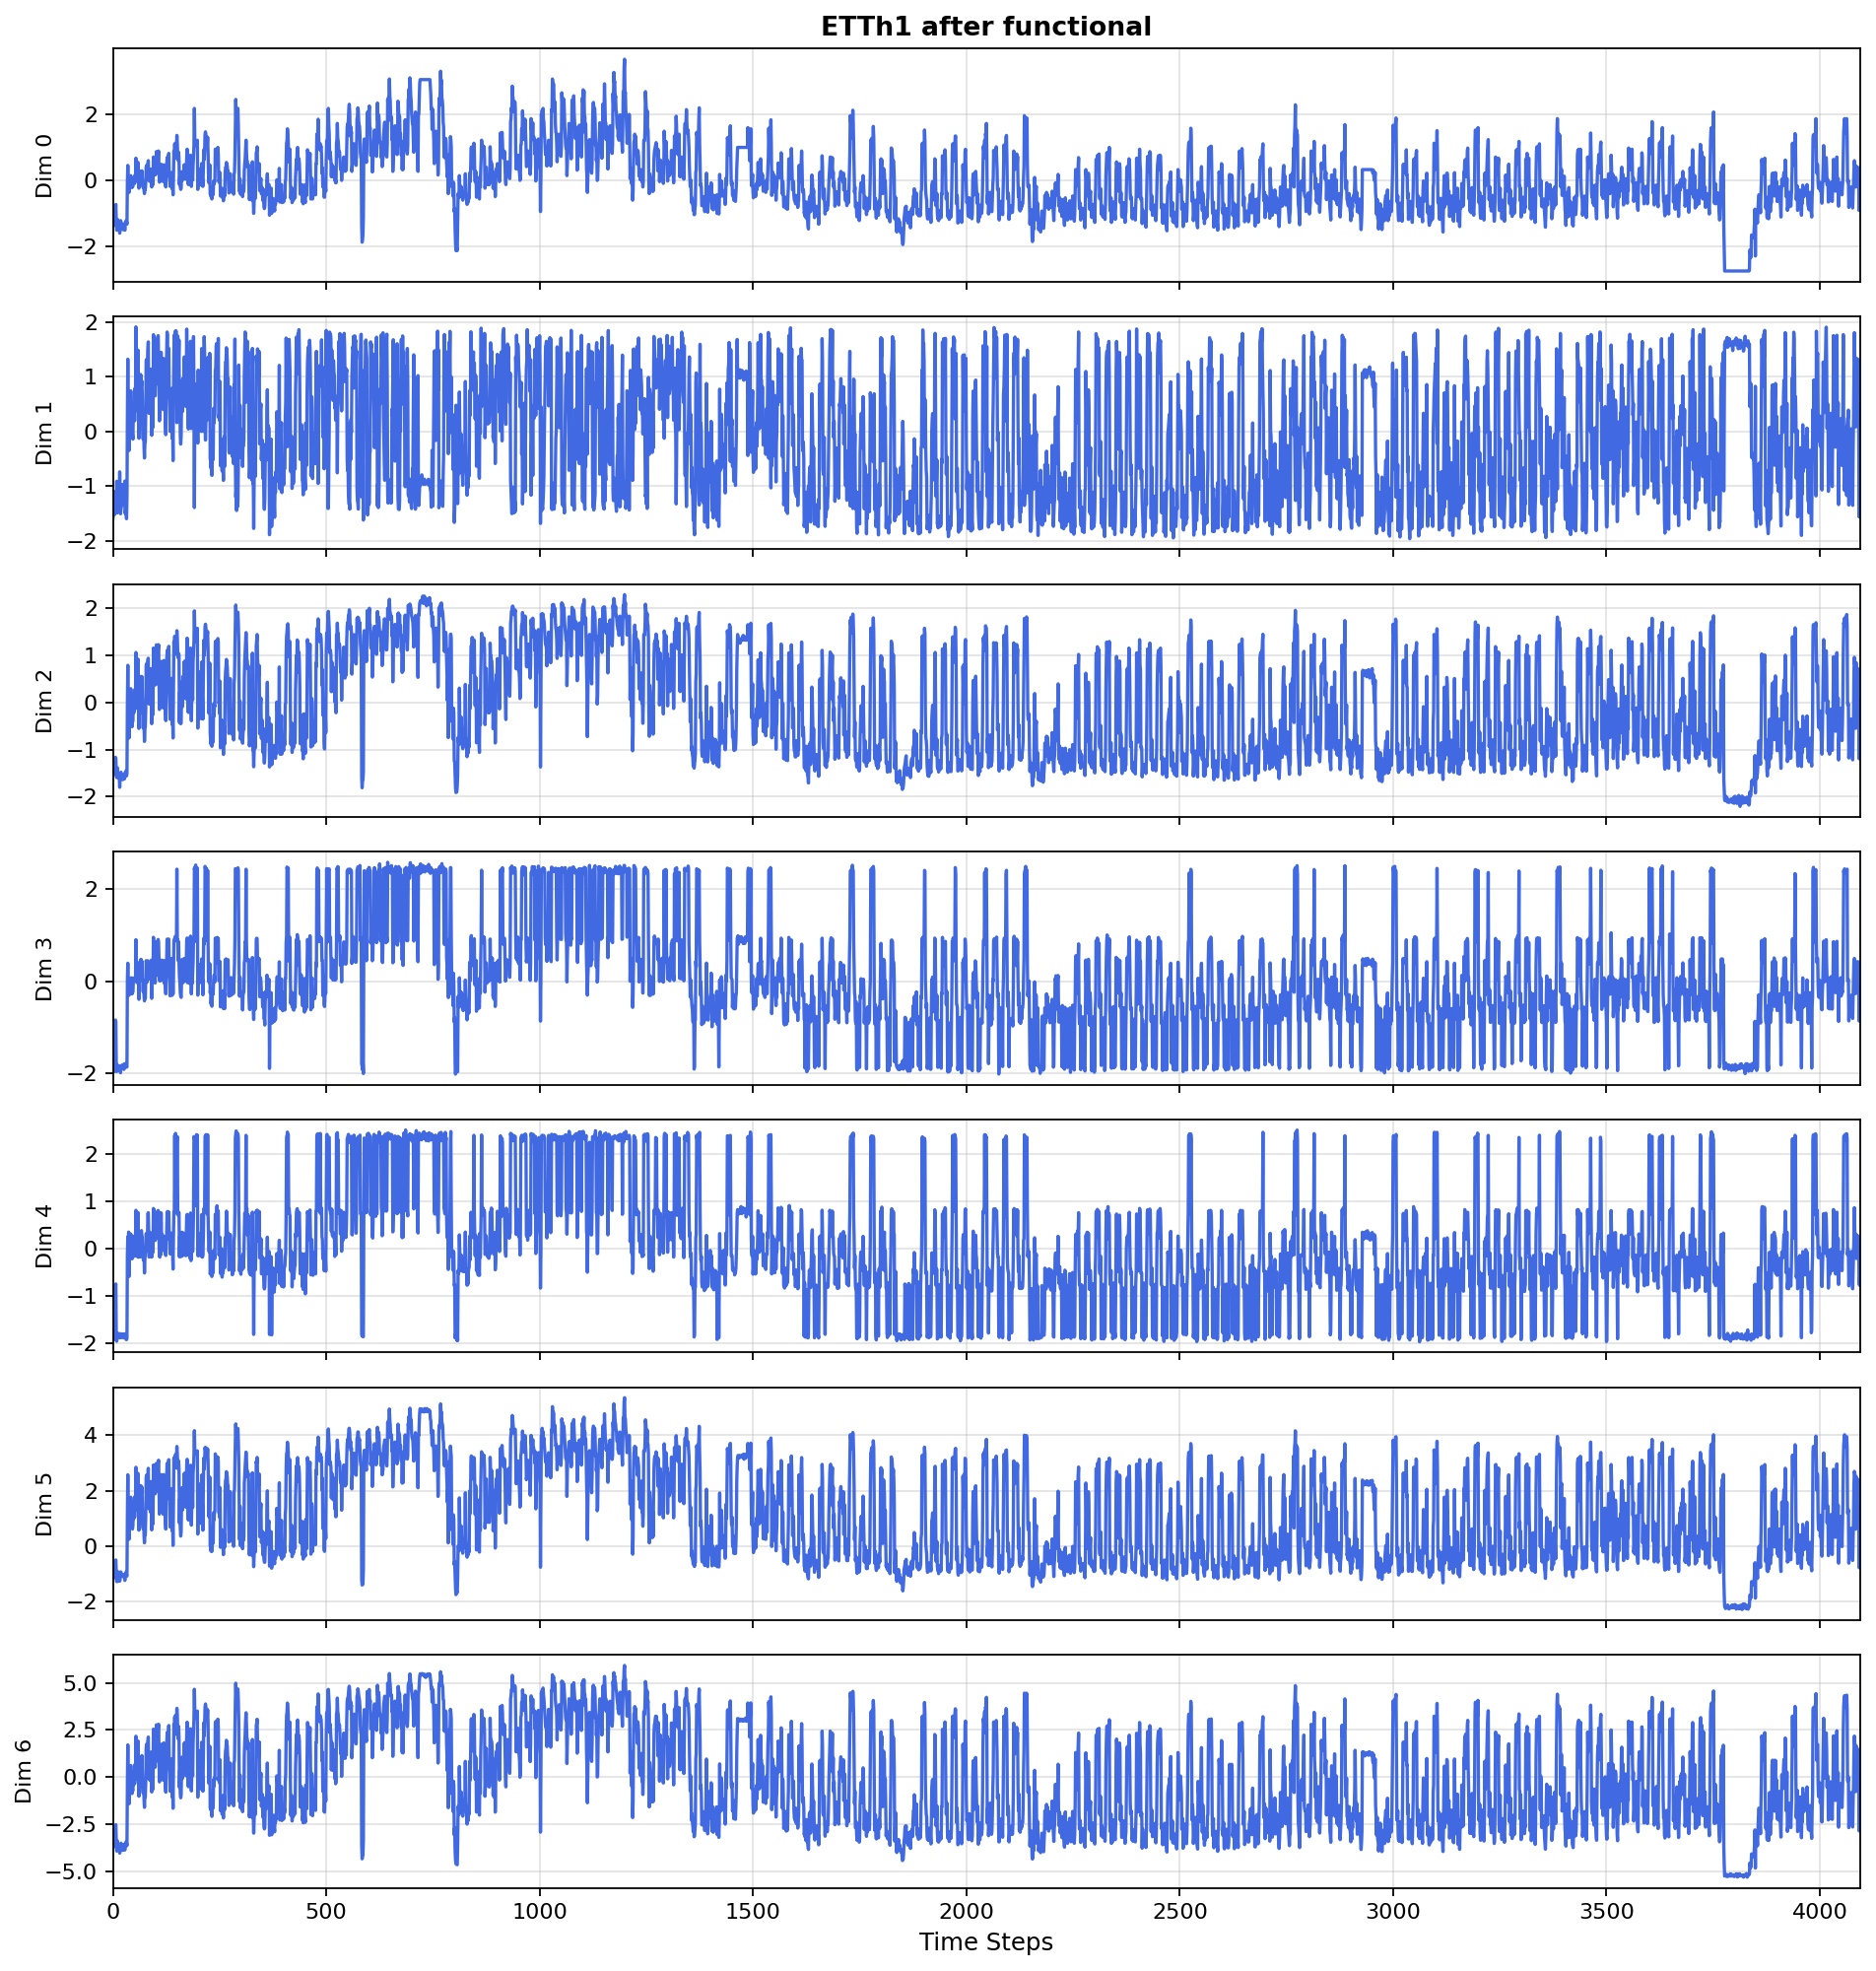

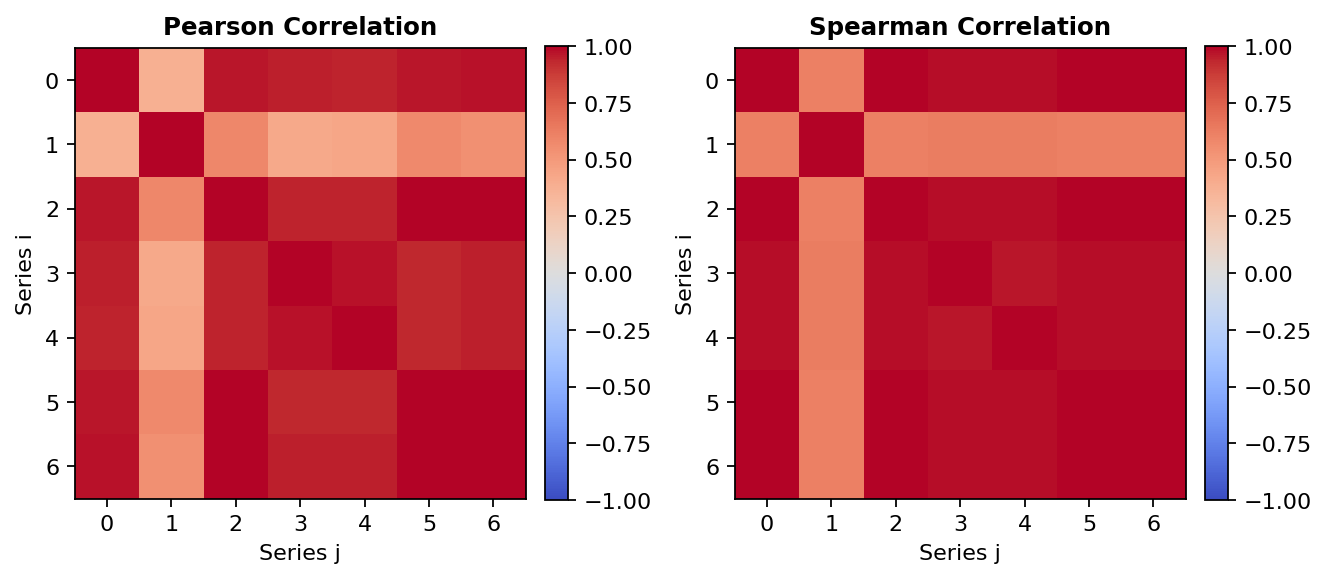

ETTh1 after linear_scm
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.152


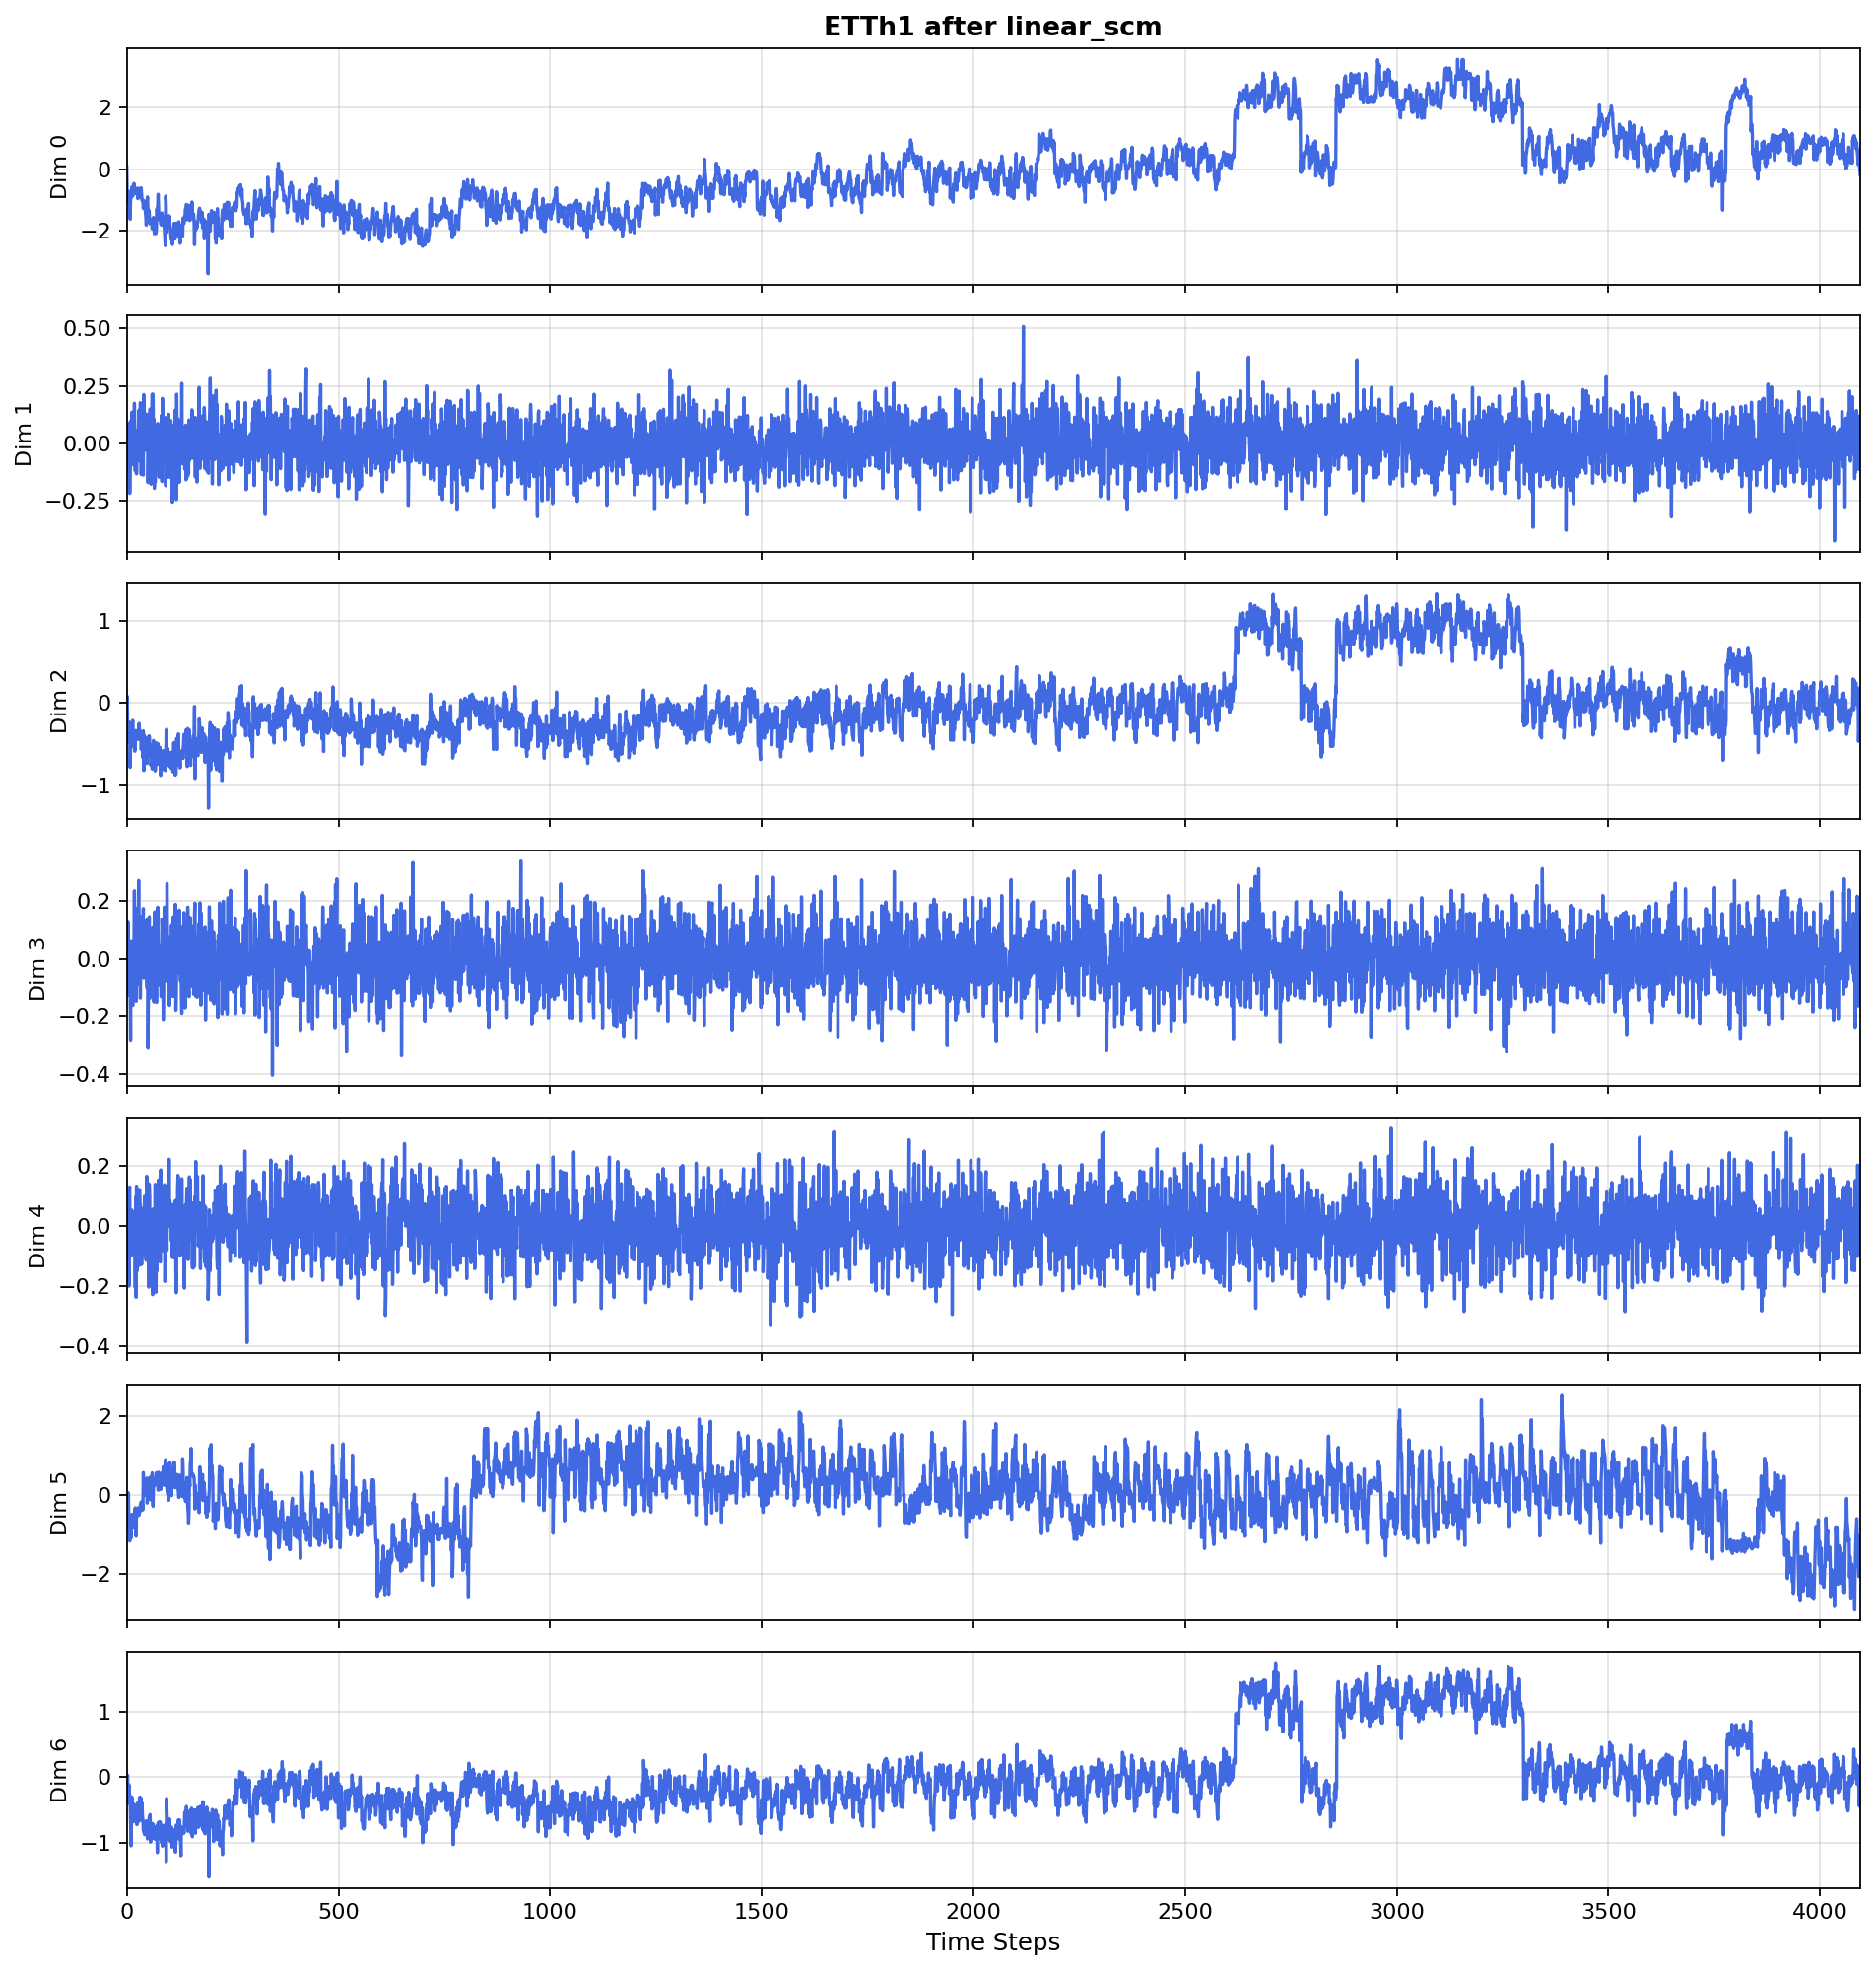

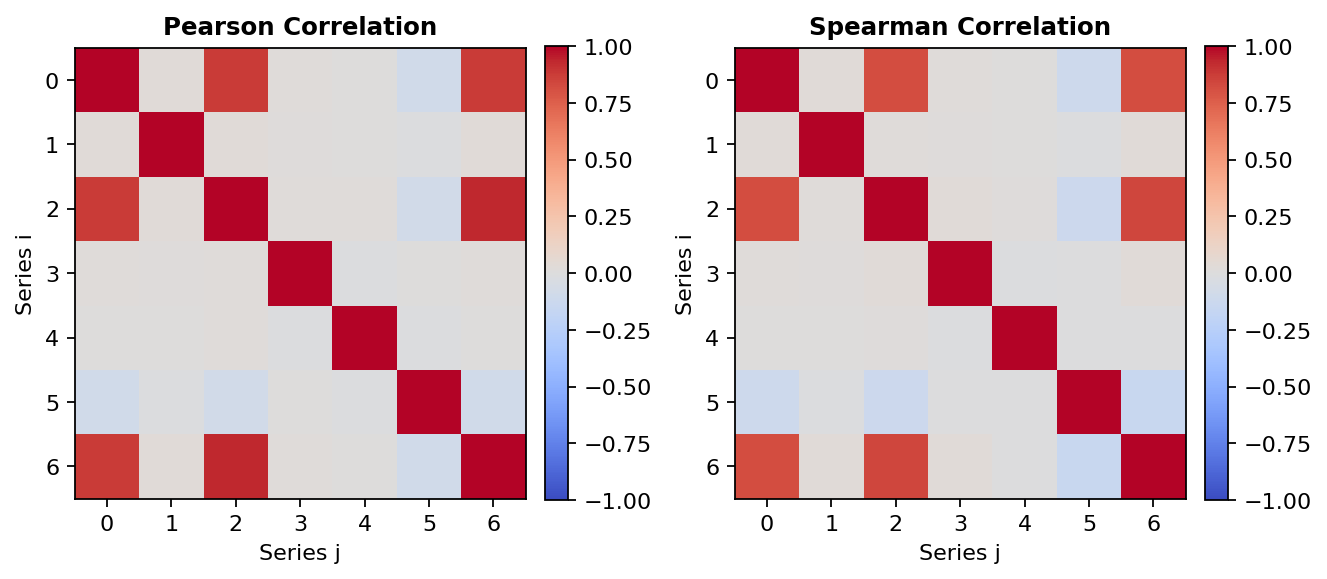

ETTh1 after cointegration
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.697


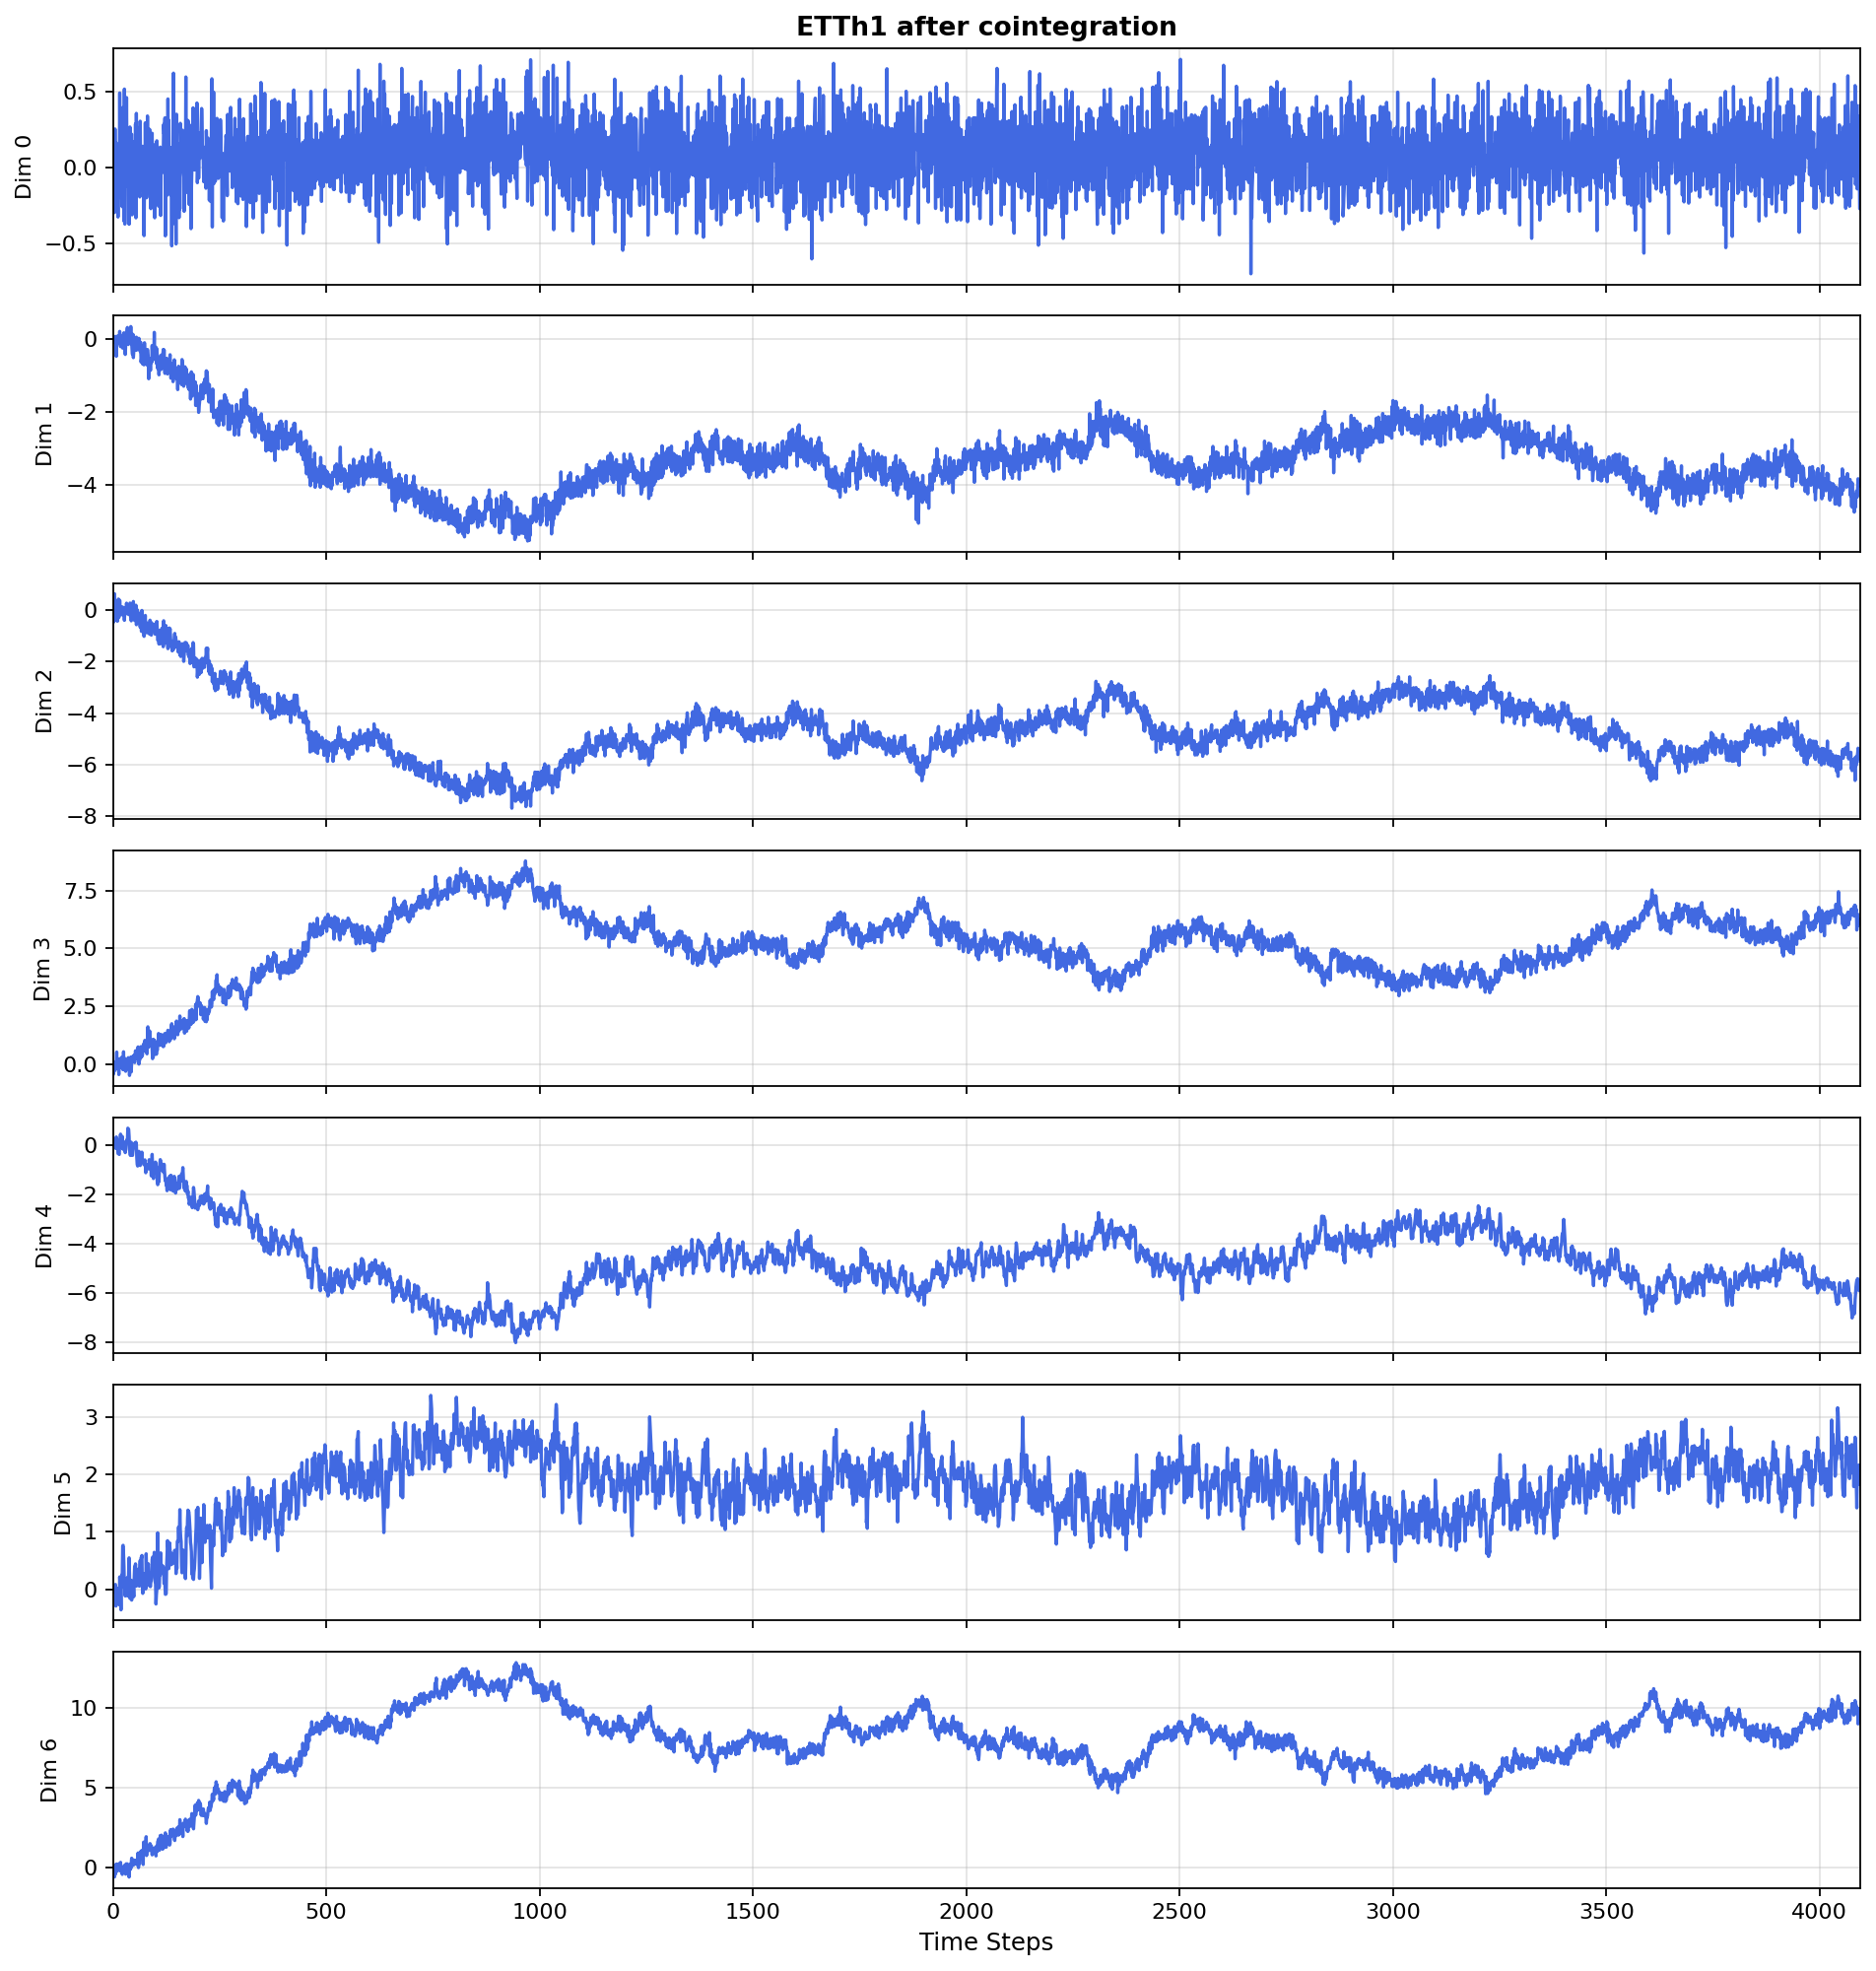

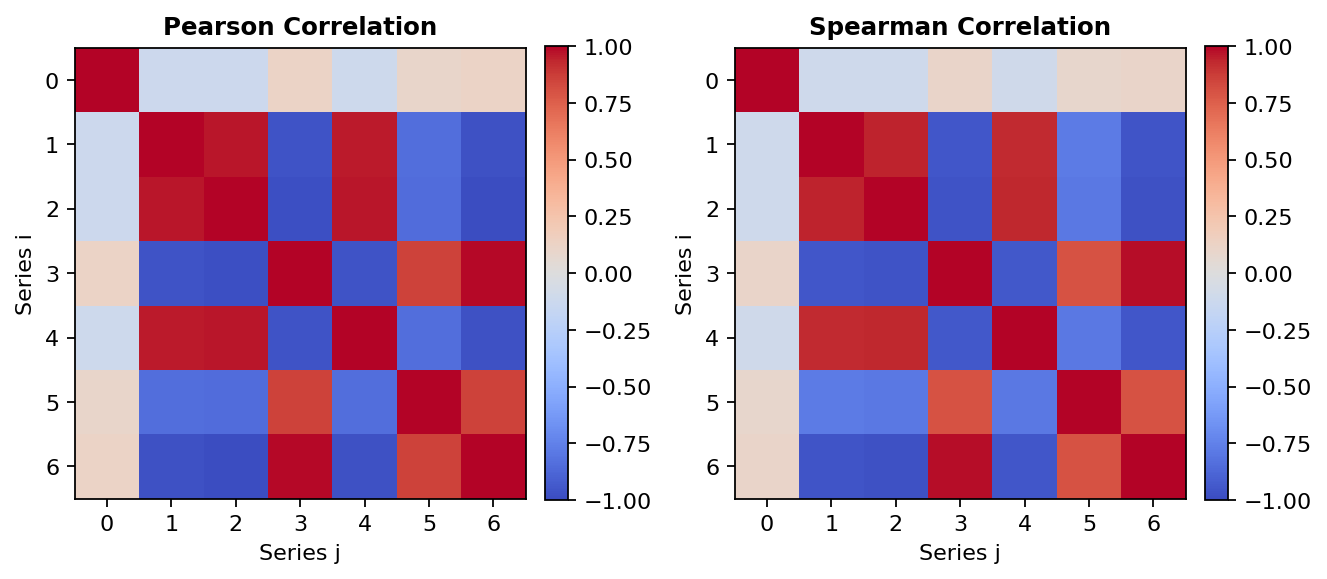

In [4]:
MECHANISMS = ["identity", "linear_mixing", "functional", "linear_scm", "cointegration"]

for i, name in enumerate(MECHANISMS):
    coupled = pipe(
        np.random.RandomState(10 + i),
        z,
        mechanism=name,
        apply_postprocessing=False,
    )
    show_series(coupled, f"ETTh1 after {name}")

## Experiment 2 — different datasets, OT pool

Stack the seven `OT` series as columns of a single `(4096, 7)` array.
This matches the paper's construction: **independently sampled univariate series from a heterogeneous pool**, then coupled.

Before coupling the channels come from different domains (electricity load, oil temperature, FX, weather), so raw cross-correlation after z-score should be weak.
Linear mixing / functional coupling should then impose a controllable joint structure.


OT pool columns:
  0: ETTh1 OT
  1: ETTh2 OT
  2: ETTm1 OT
  3: ETTm2 OT
  4: exchange_rate OT
  5: weather OT
  6: electricity OT
Cross-dataset OT pool (z-scored, before coupling)
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.236


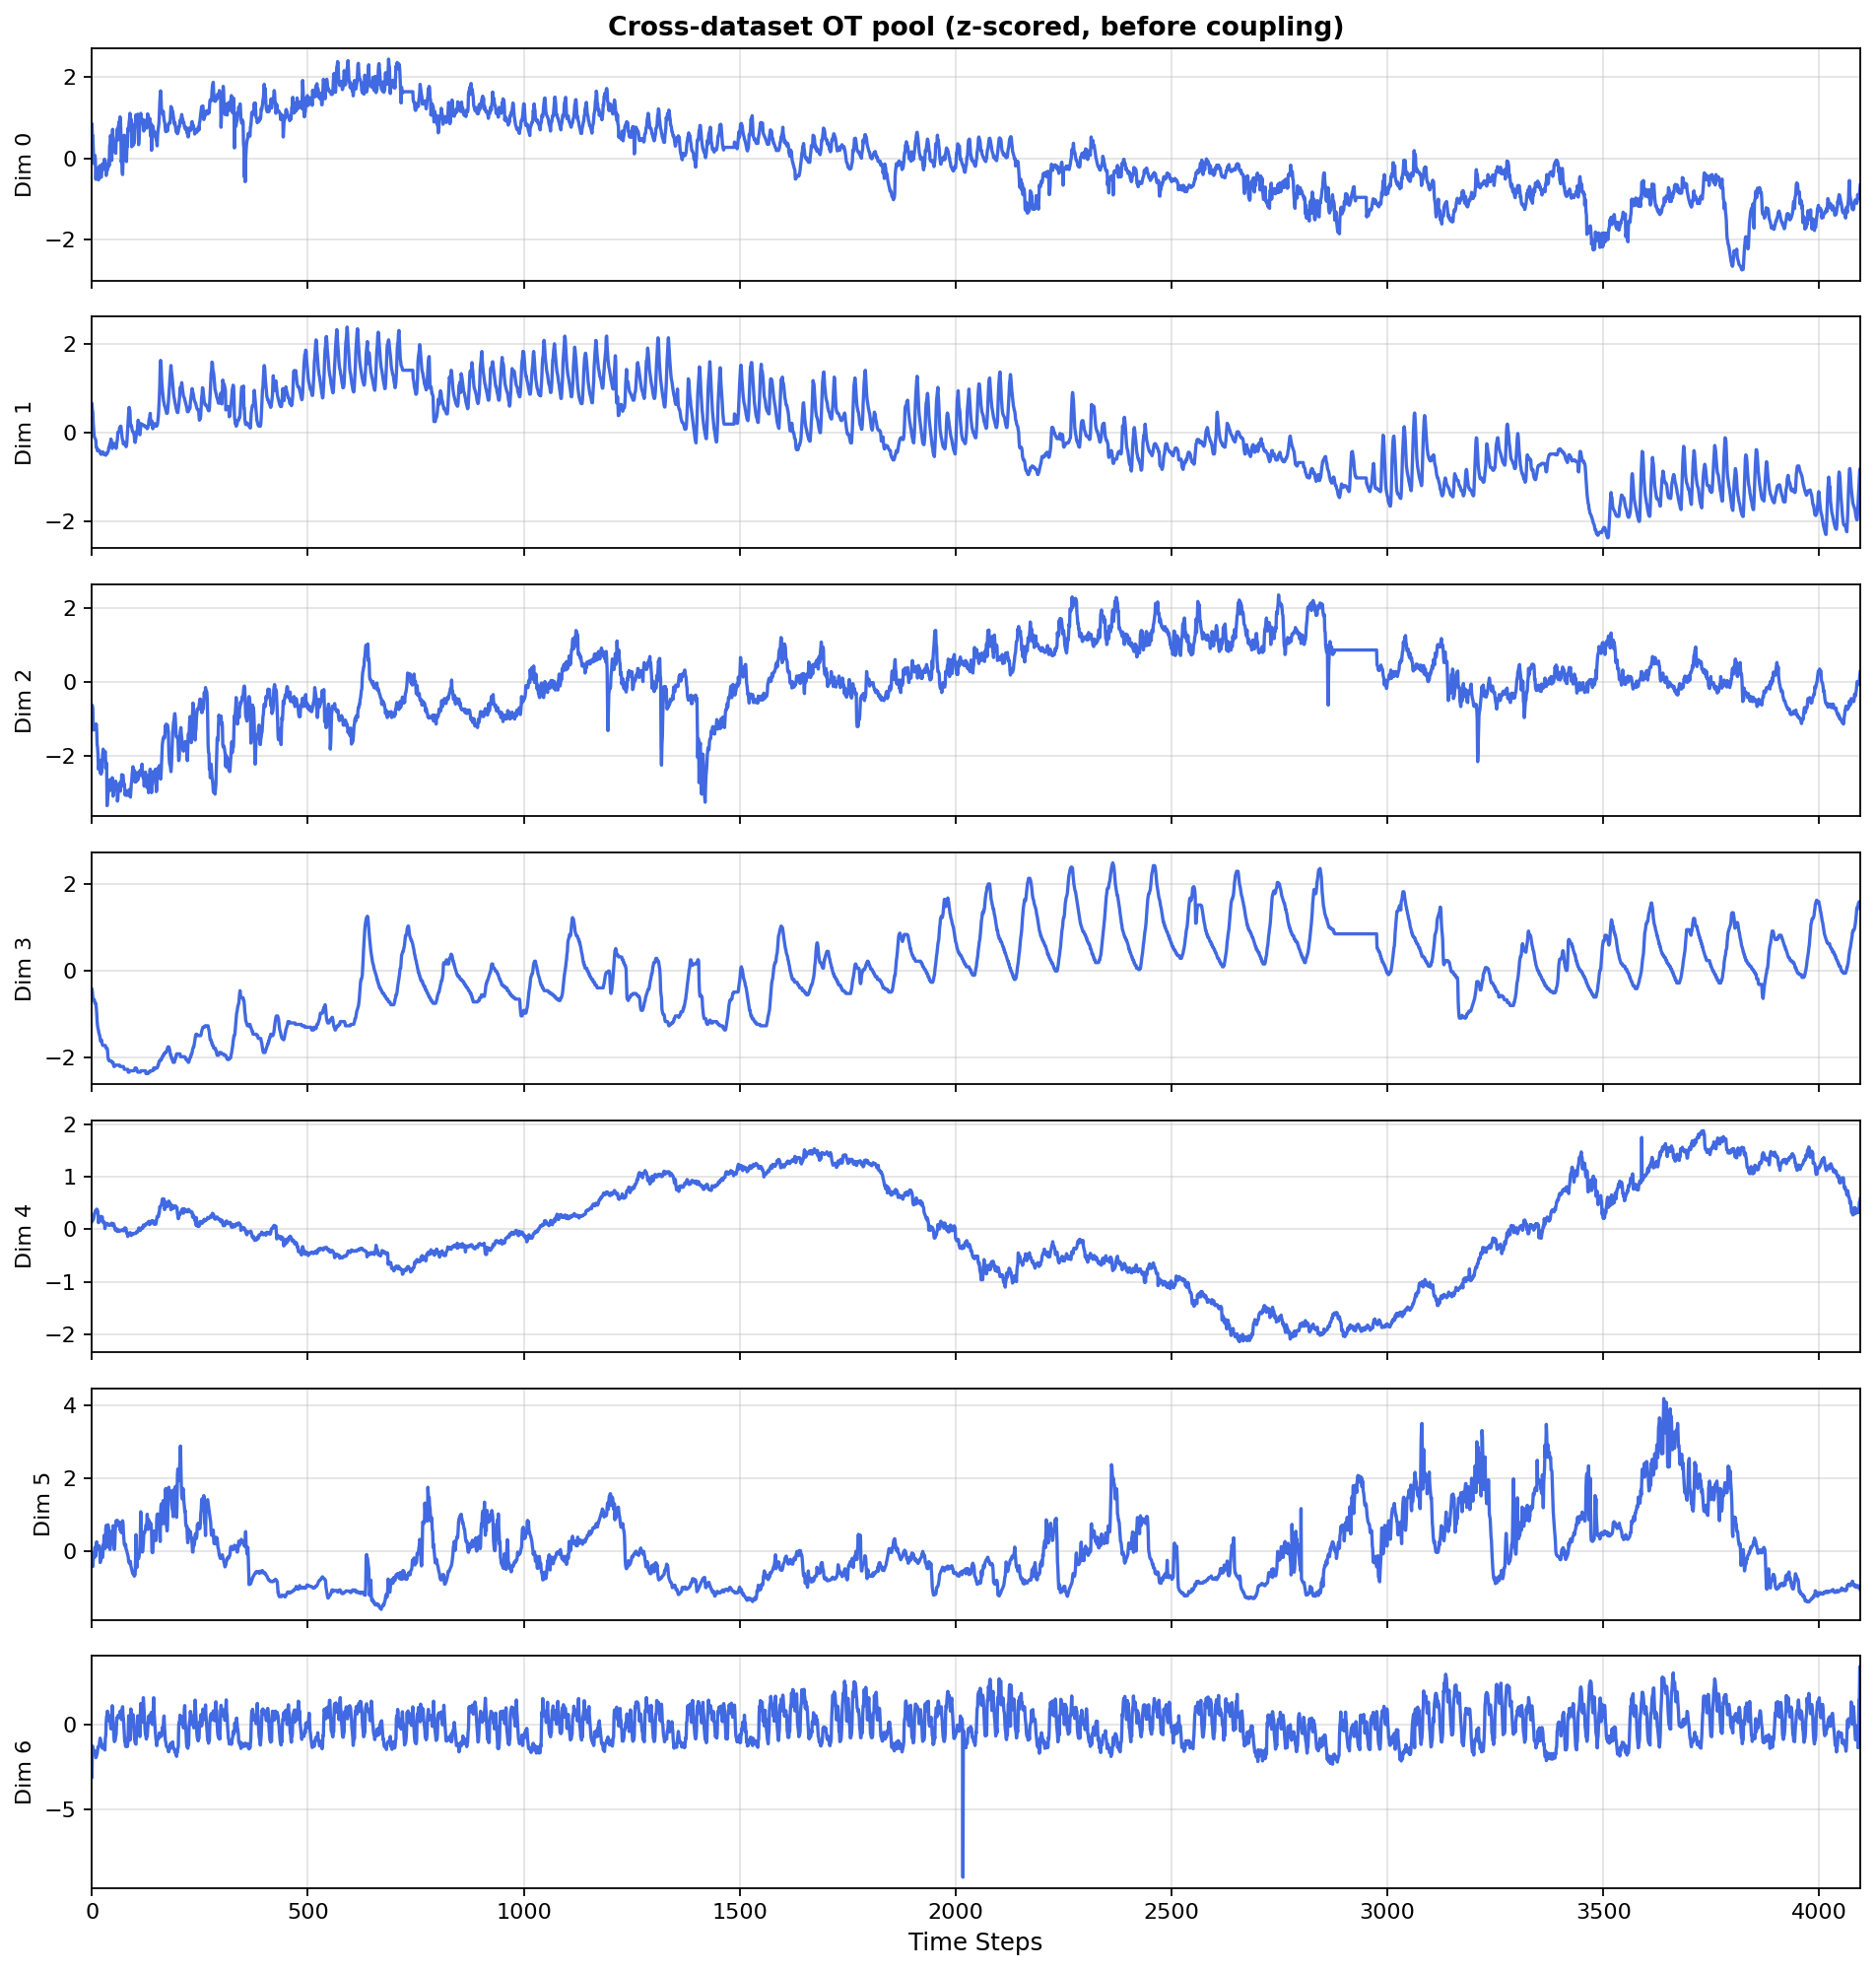

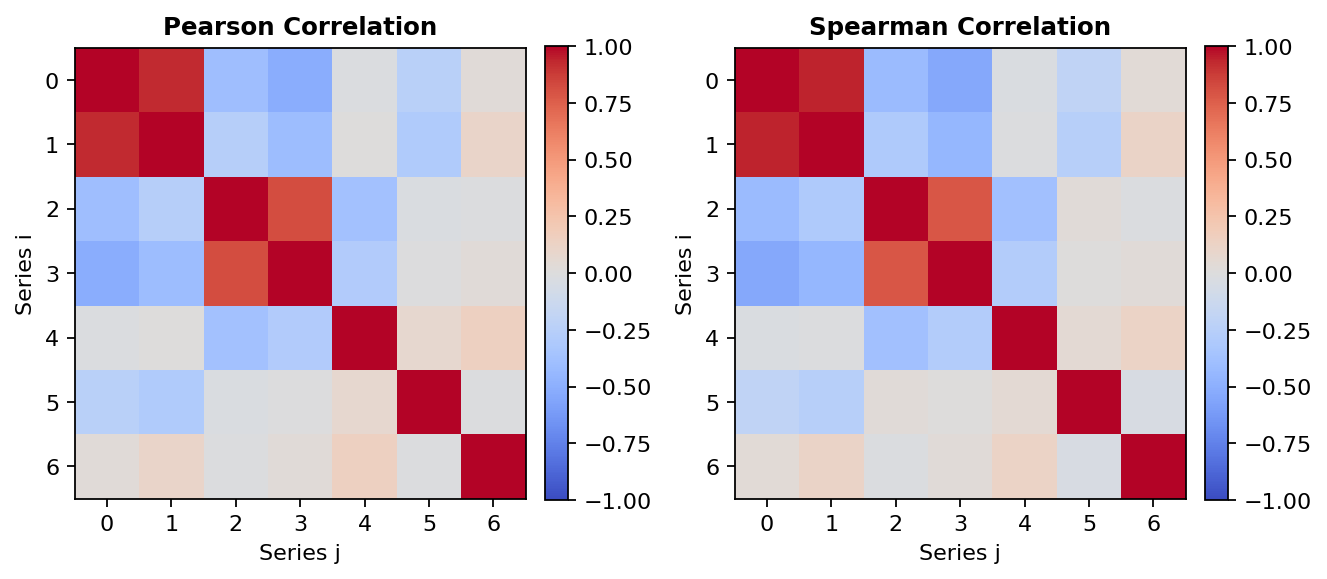

In [ ]:
ot_pool = np.column_stack([load_univariate(name) for name in ot_names])
z_ot = z_score_normalization(ot_pool)
assert z_ot is not None
print("OT pool columns:")
for i, name in enumerate[str](ot_names):
    print(f"  {i}: {name} OT")

show_series(z_ot, "Cross-dataset OT pool (z-scored, before coupling)")

OT pool after identity
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.236


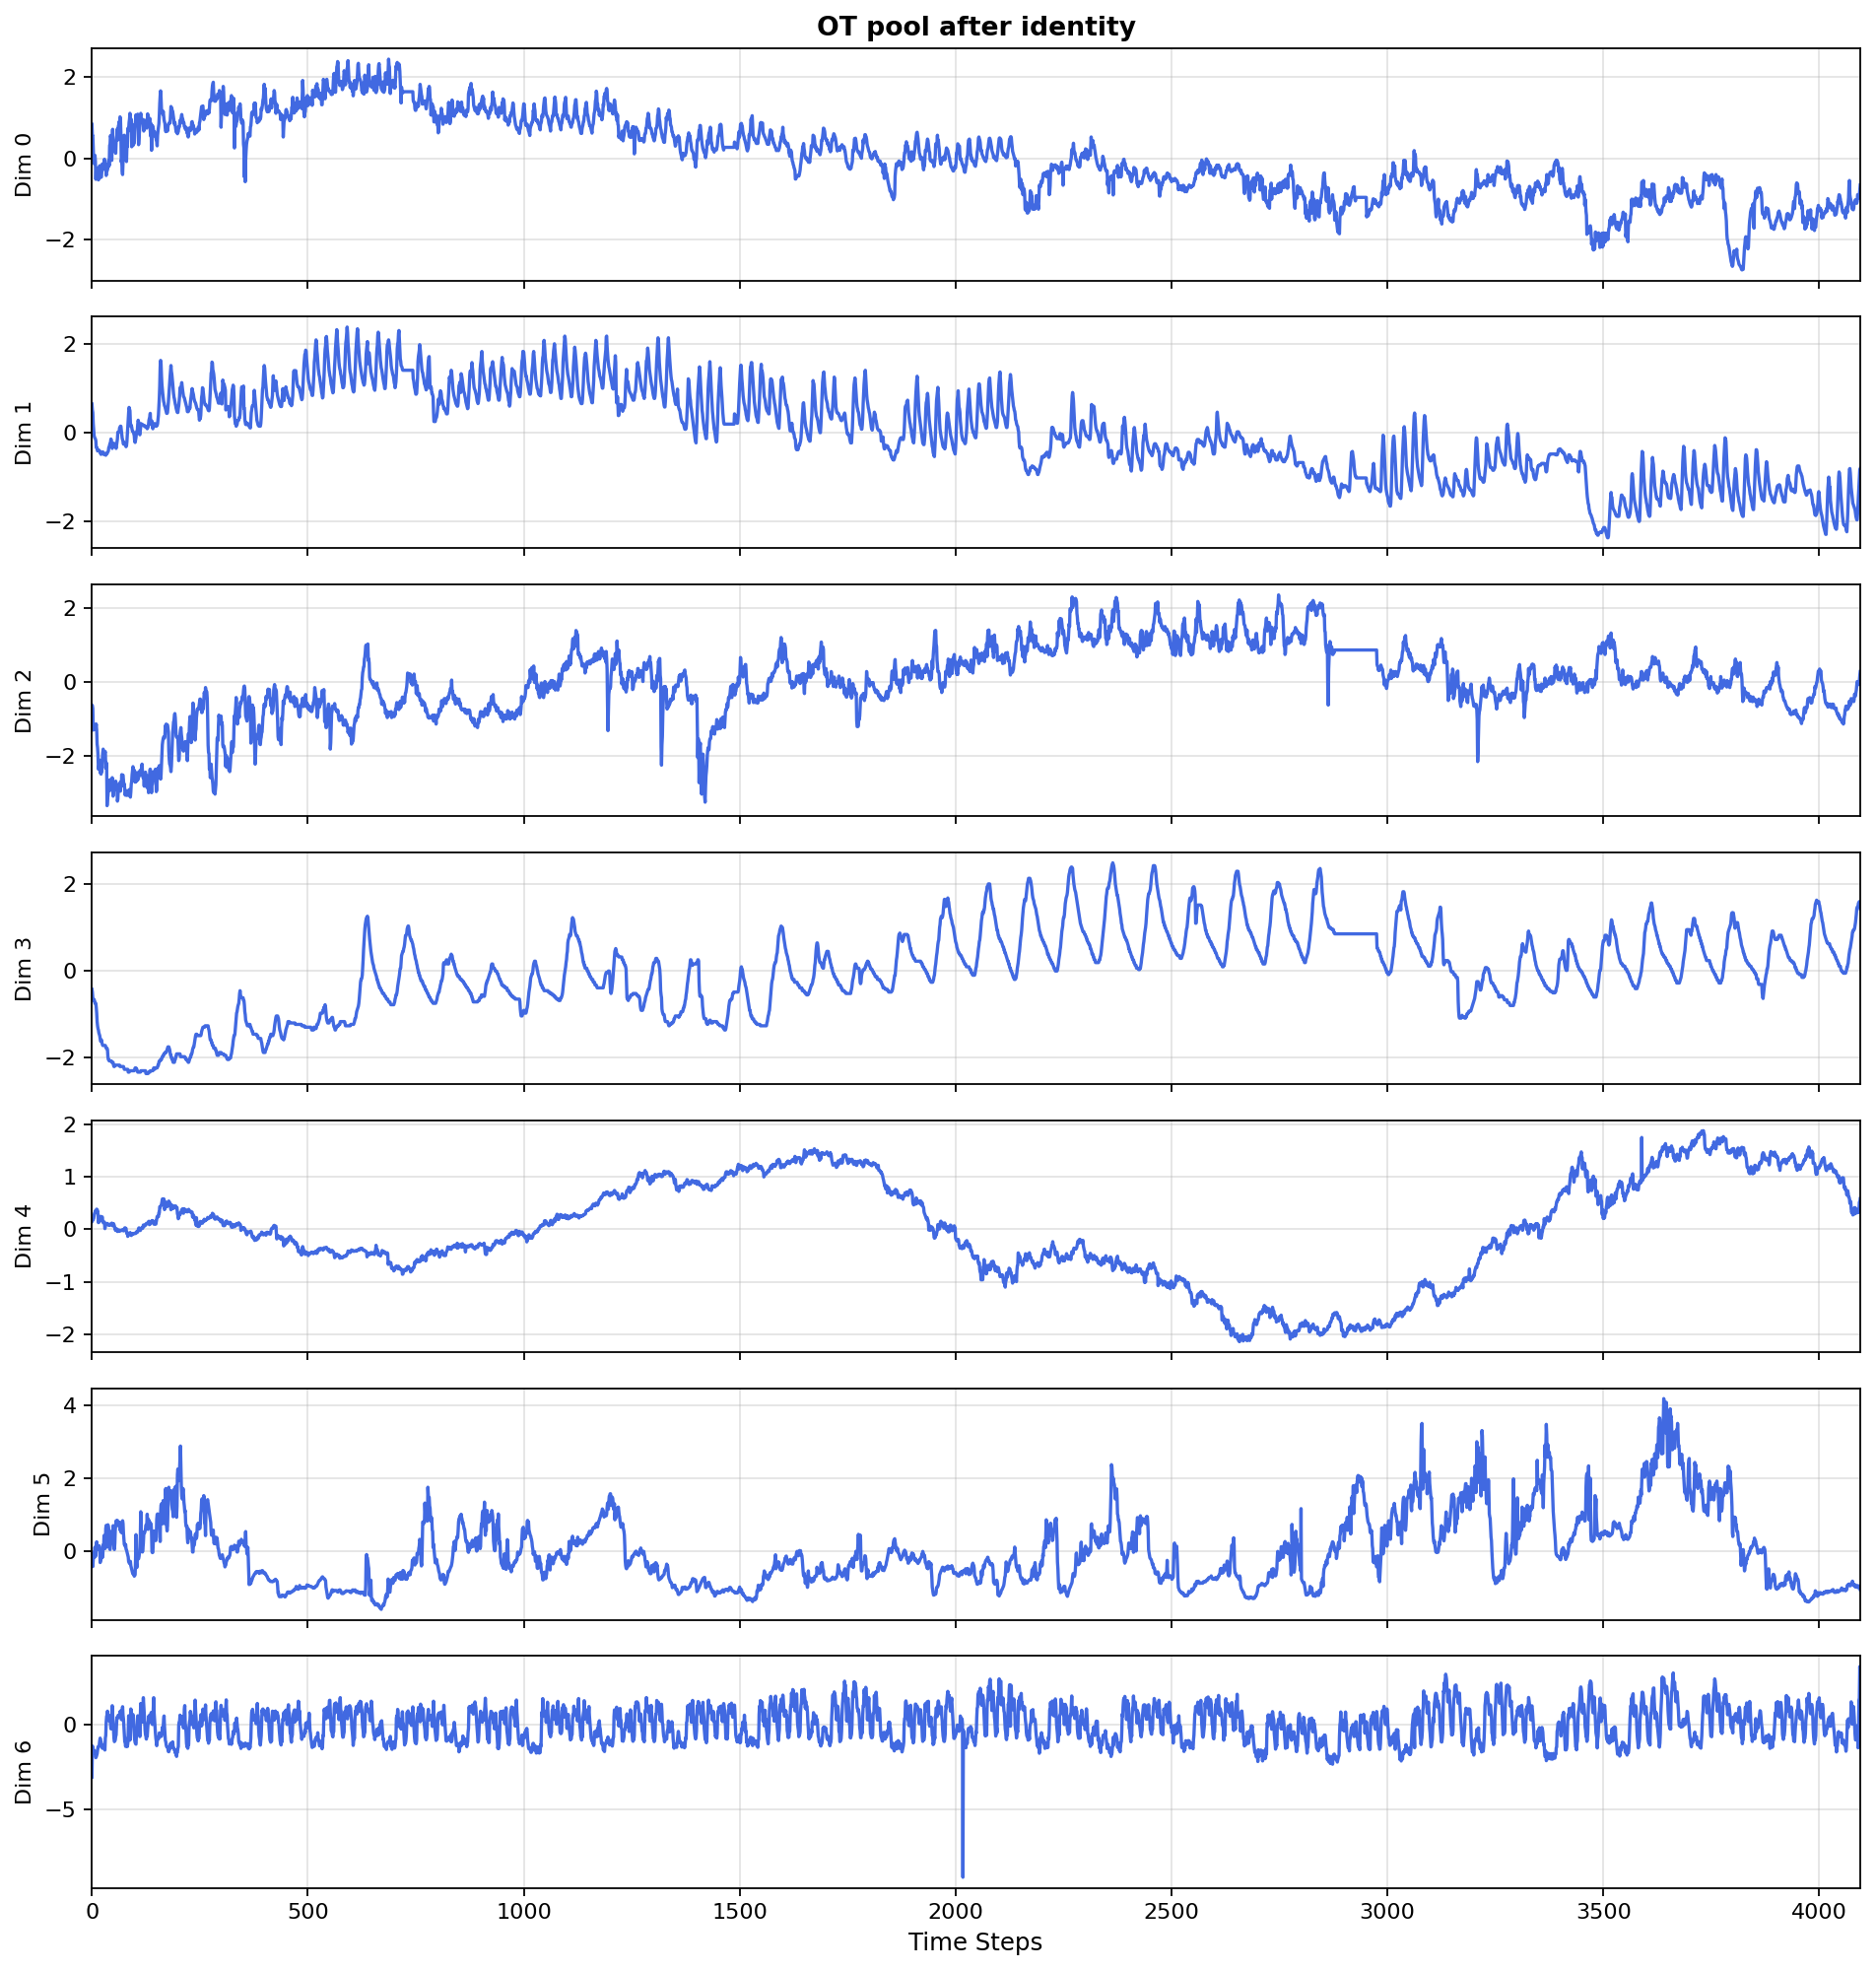

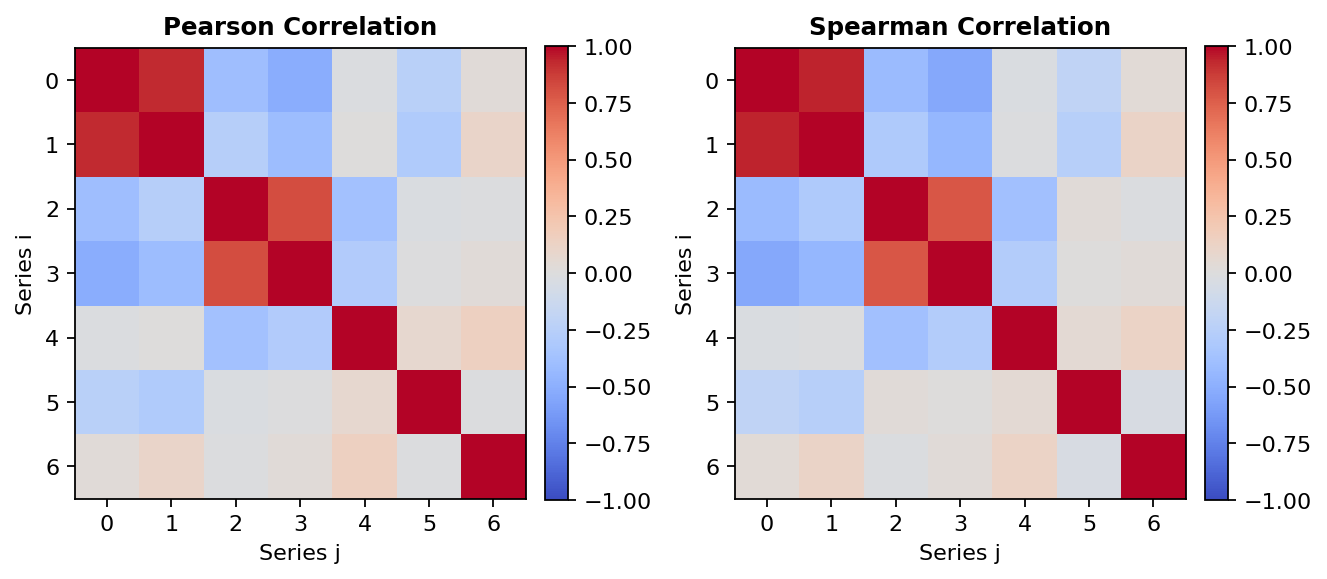

OT pool after linear_mixing
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.238


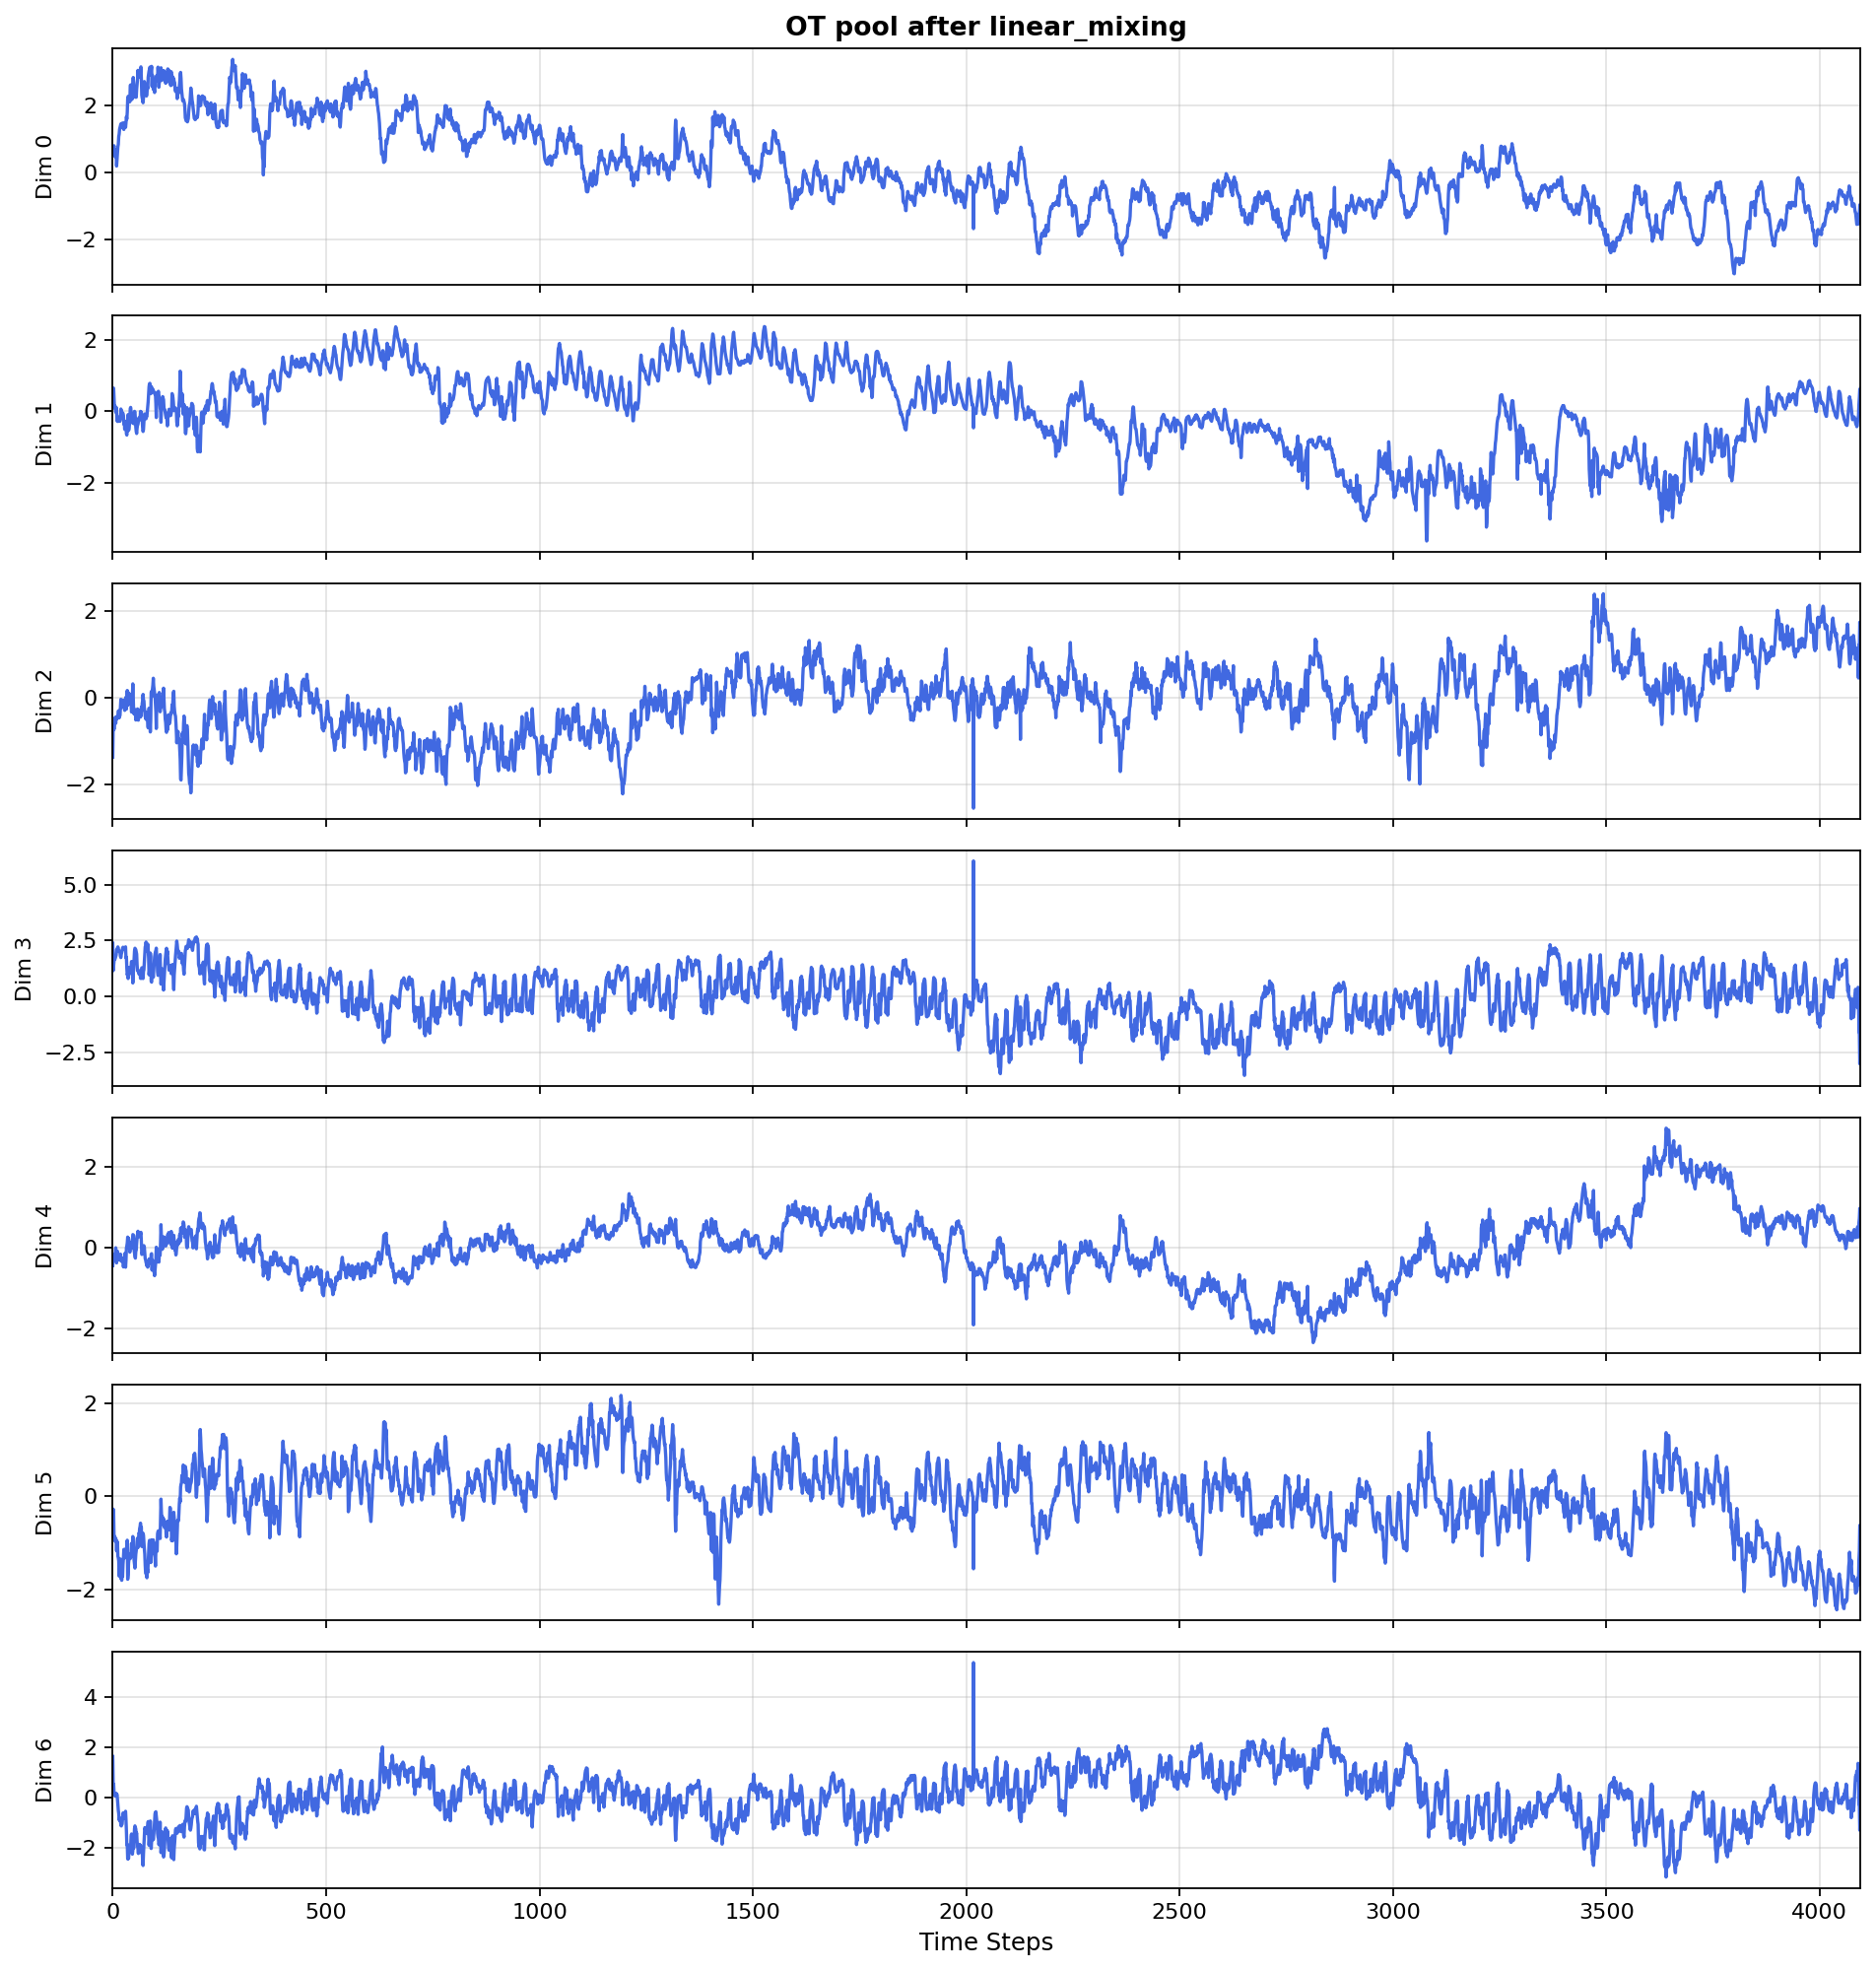

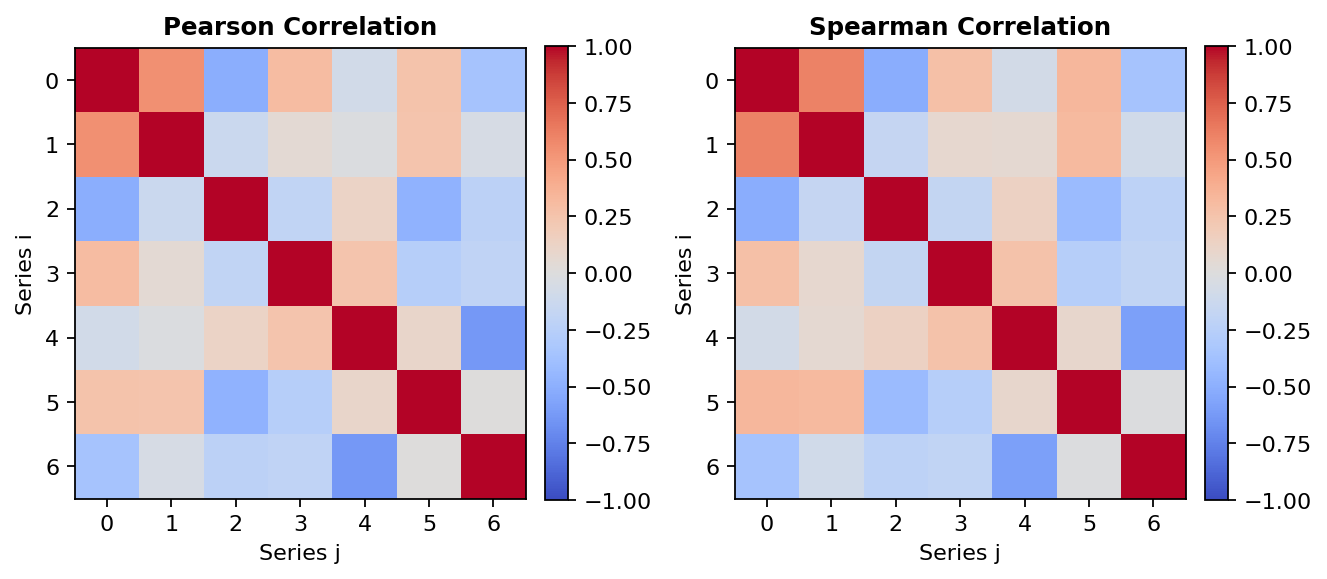

OT pool after functional
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.811


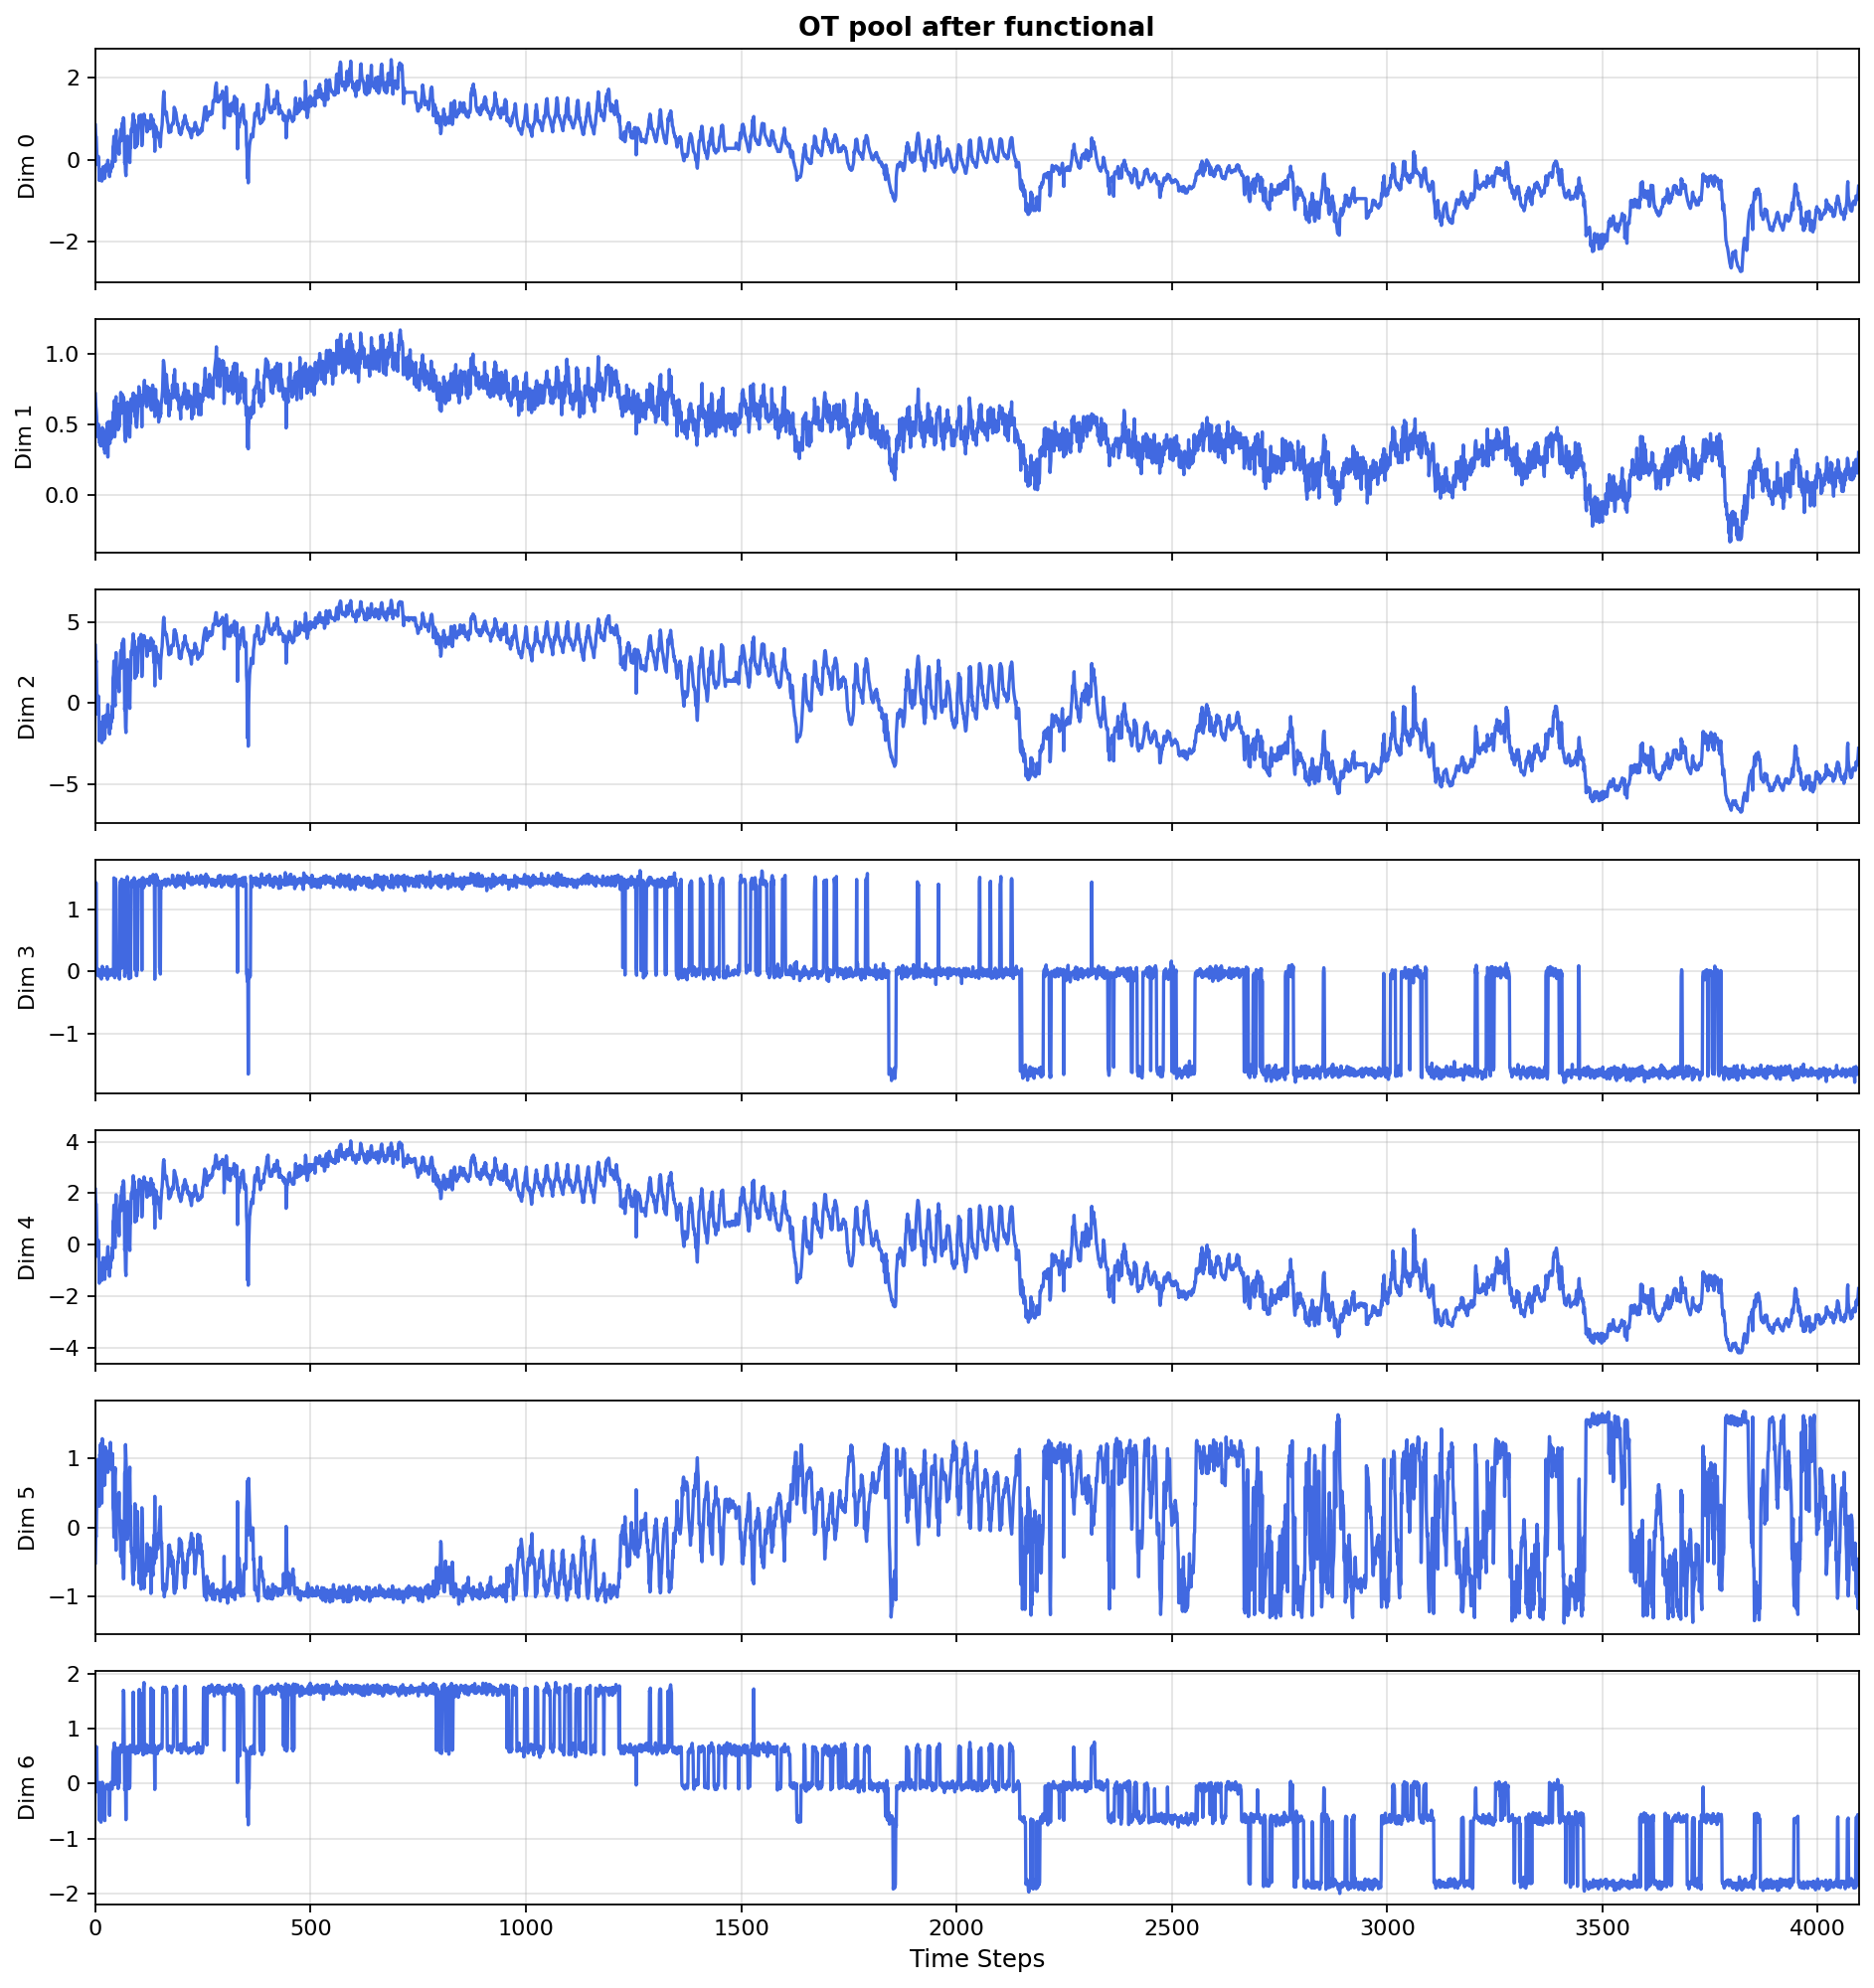

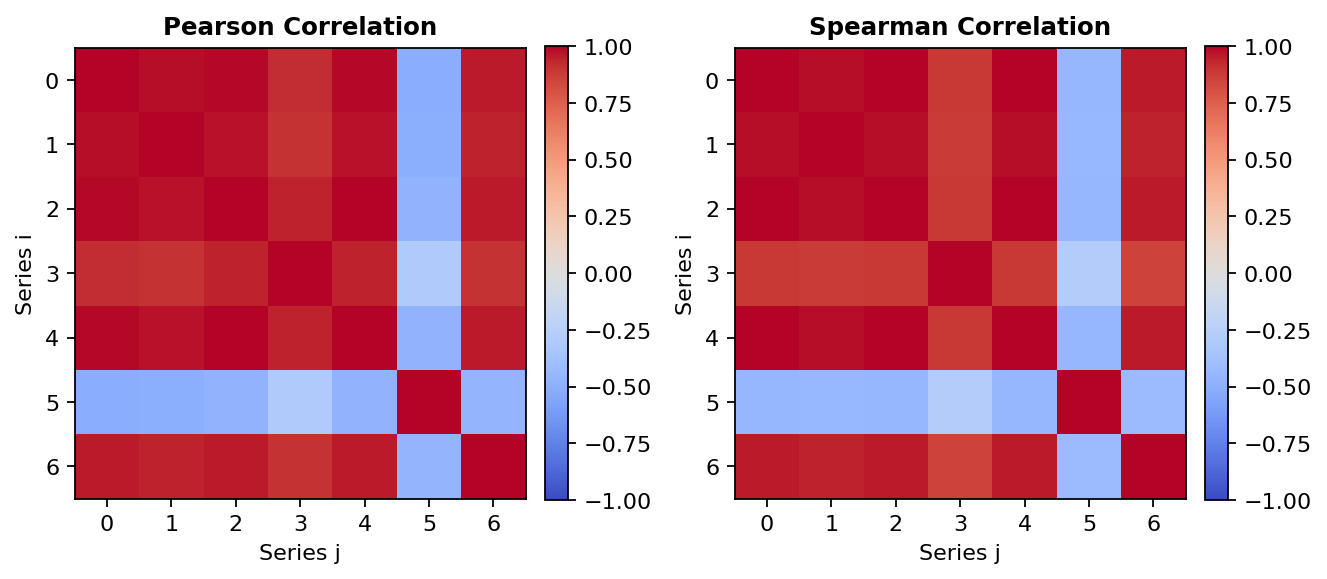

OT pool after linear_scm
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.089


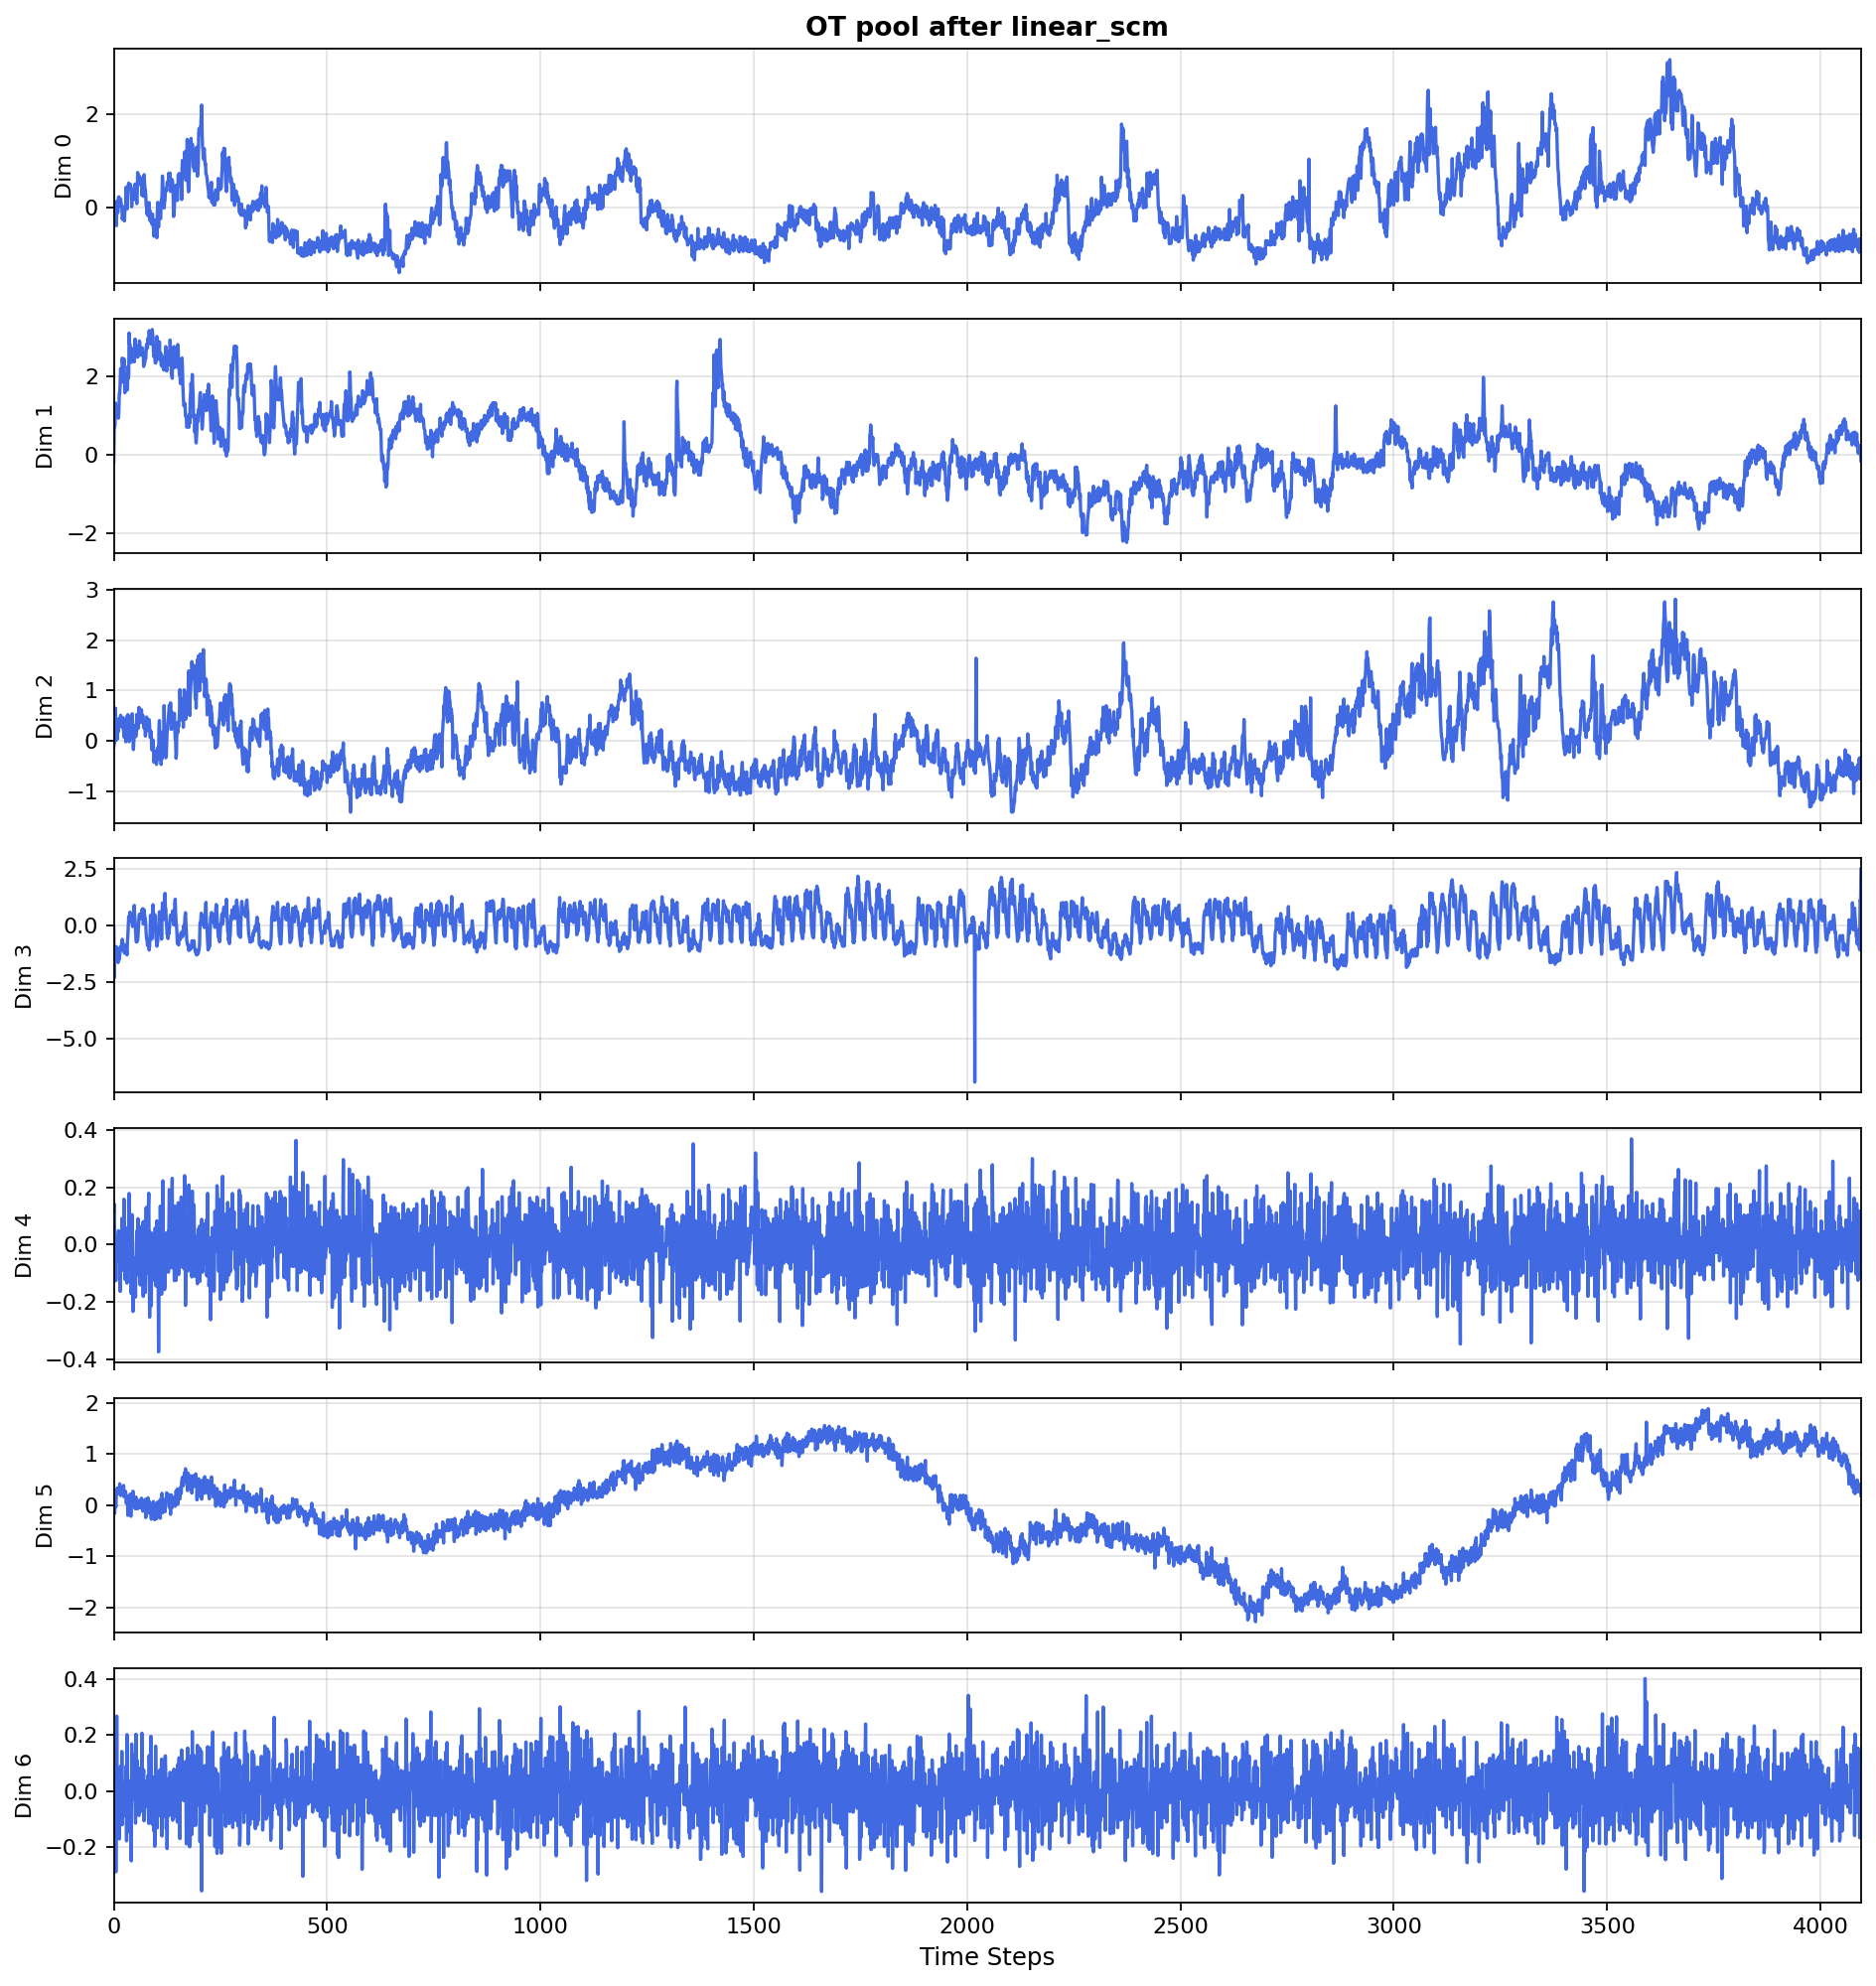

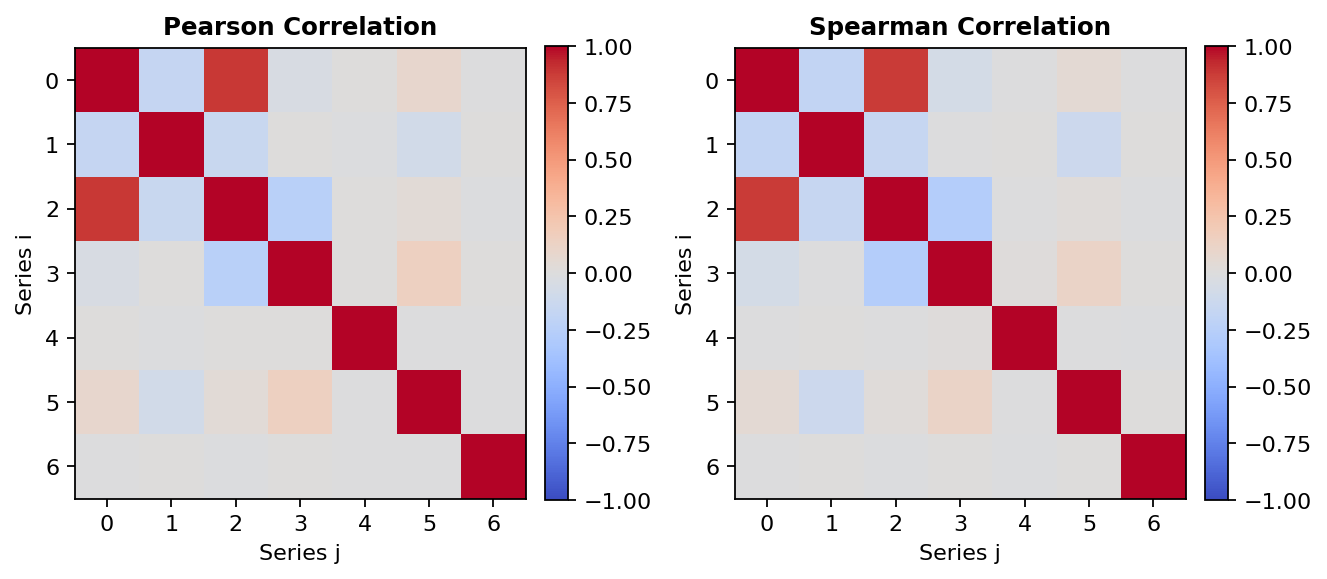

OT pool after cointegration
  shape (T, Q): (4096, 7)
  mean |Pearson| off-diagonal: 0.566


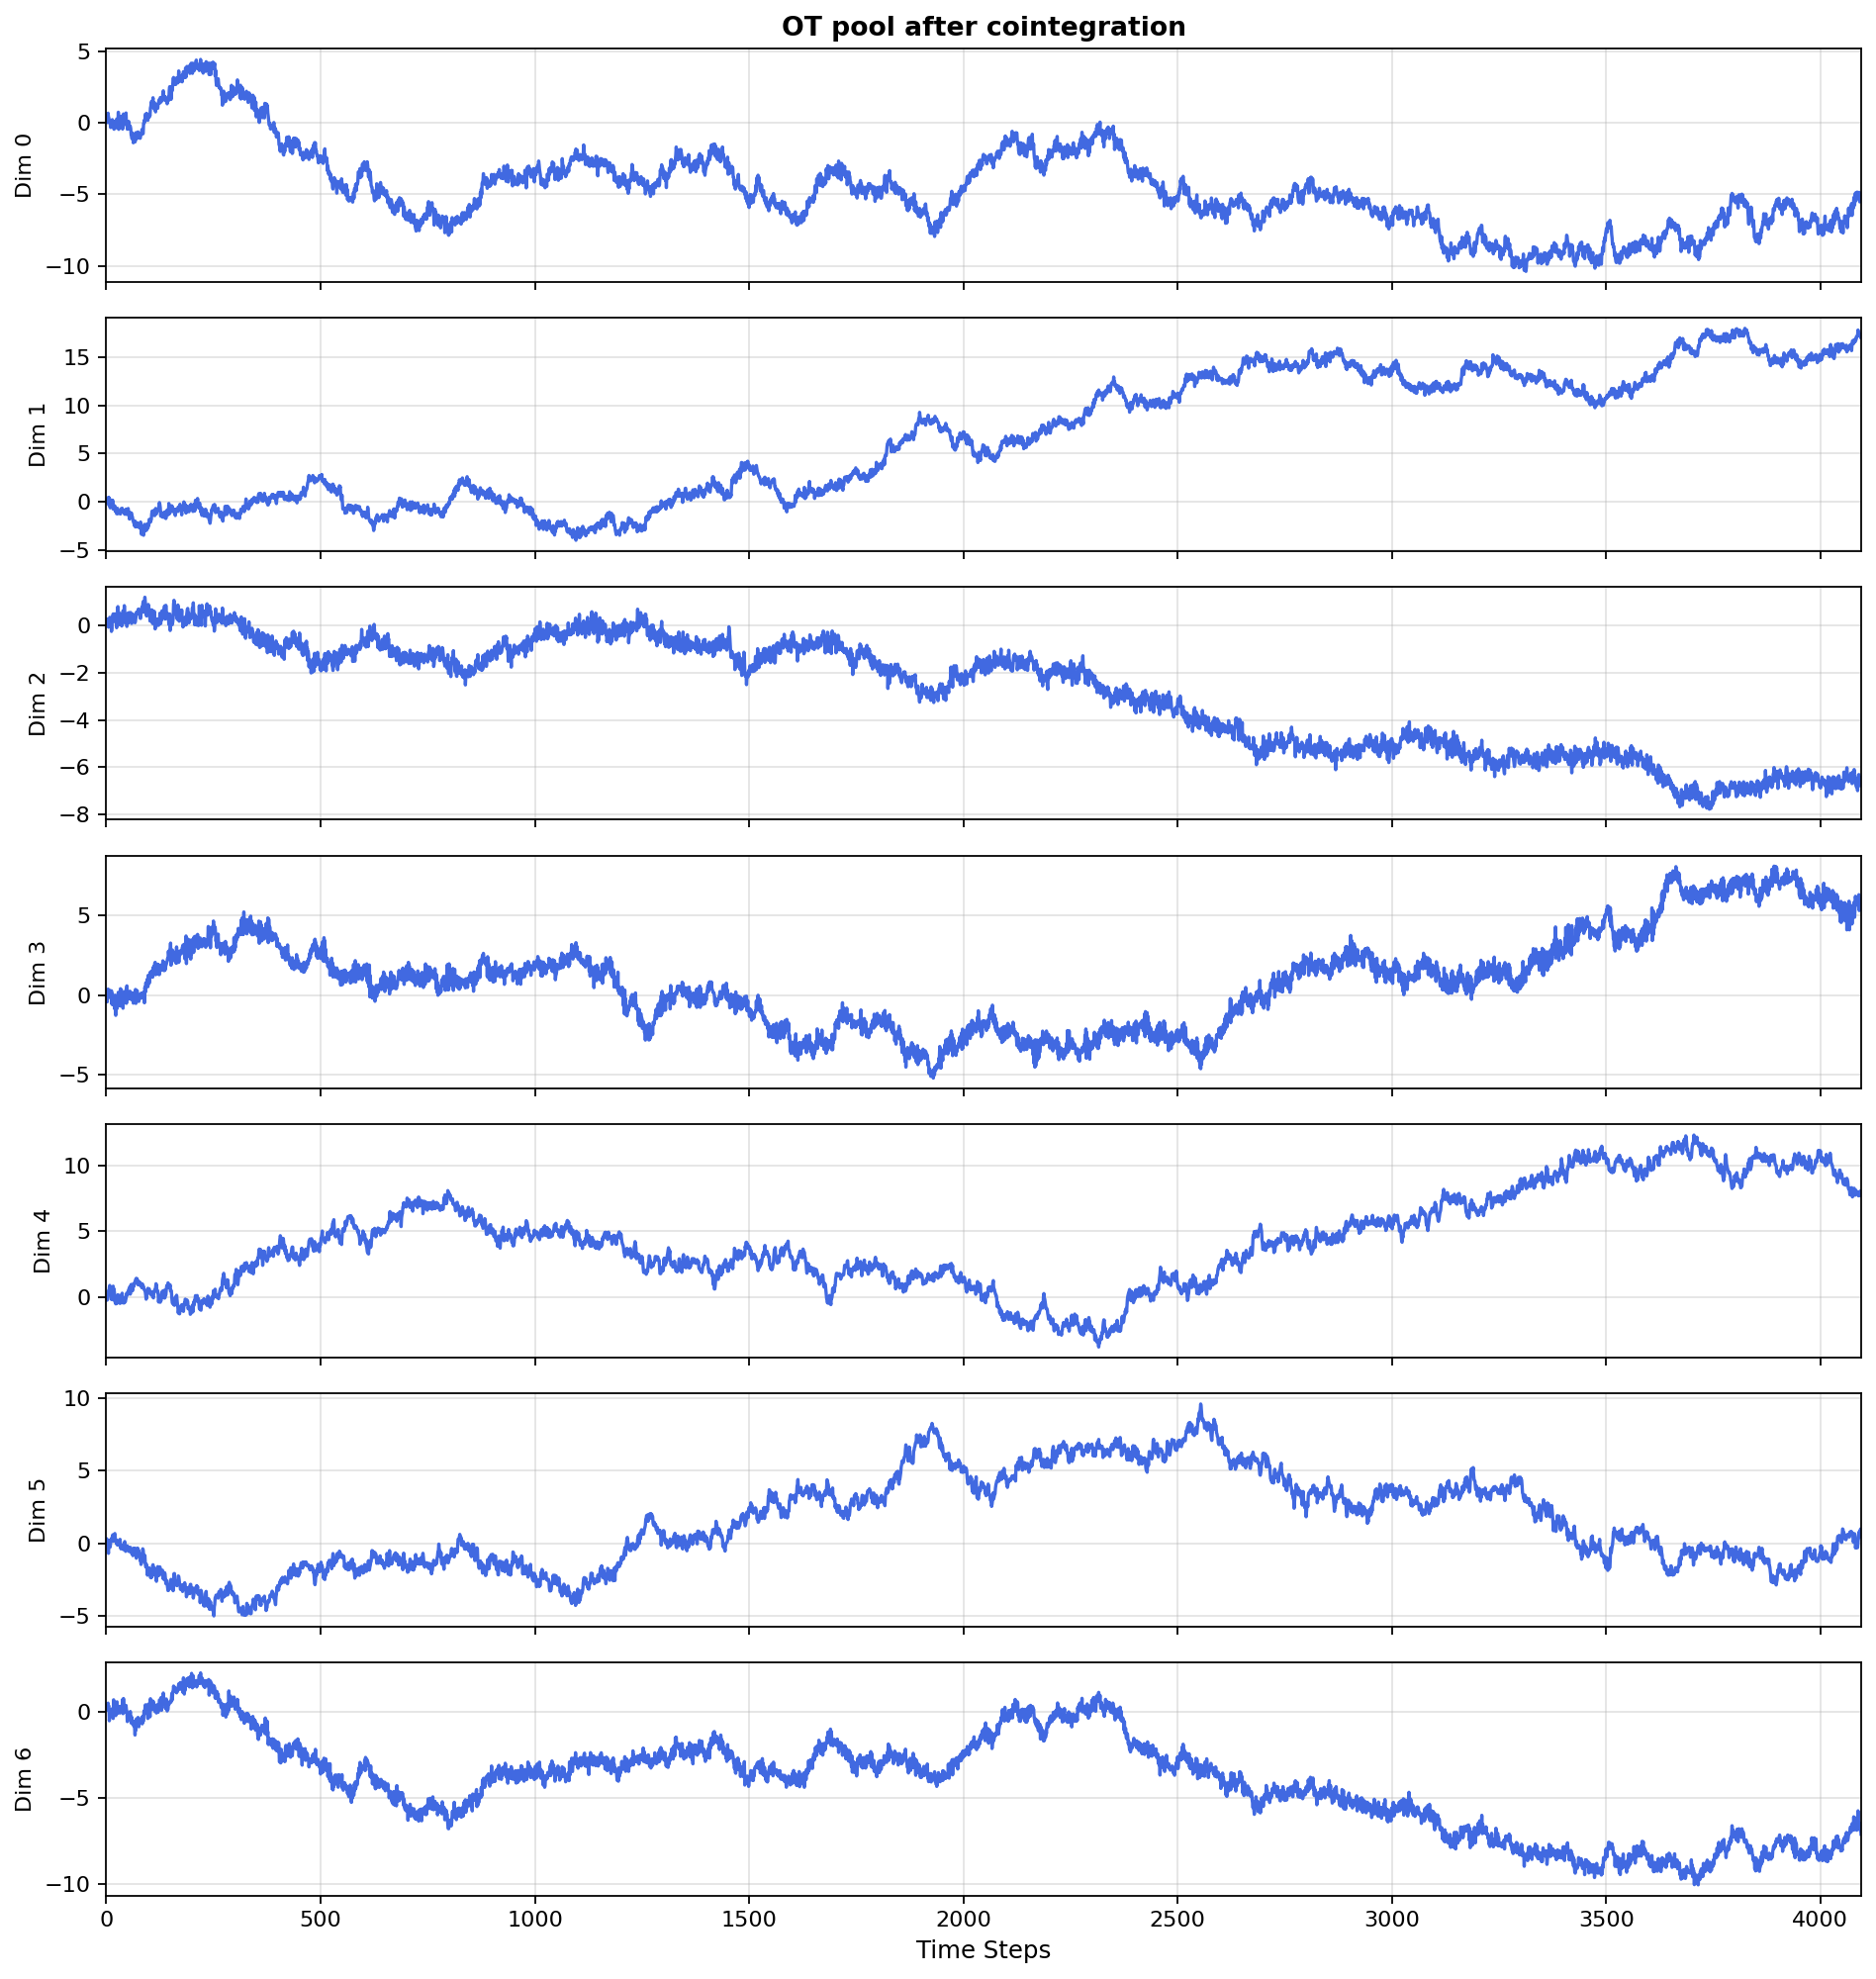

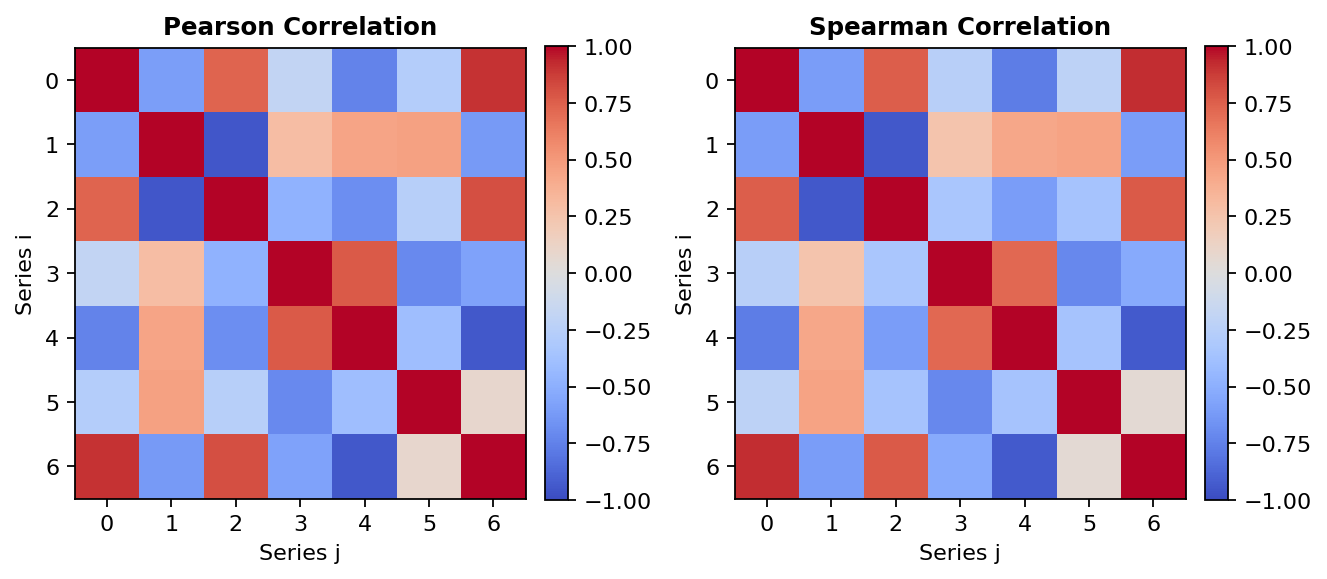

In [6]:
for i, name in enumerate(MECHANISMS):
    coupled = pipe(
        np.random.RandomState(20 + i),
        z_ot,
        mechanism=name,
        apply_postprocessing=False,
    )
    show_series(coupled, f"OT pool after {name}")

## What the two experiments show

- **`identity`**: correlation is unchanged (pass-through). Use it as the baseline for both protocols.
- **`linear_mixing`**: $x = A z$ creates a dense correlation pattern from possibly weak raw dependence — this is the factor-model augmentation.
- **`functional`**: all channels become functions of column 0, so dependence concentrates on the first input (ETTh1 `HUFL`, or ETTh1 OT in the cross-dataset pool).
- **`linear_scm`**: dependence is sparser and lagged; root nodes look like noise rather than the original real series.
- **`cointegration`**: the real content disappears; the output is a fresh random-walk / AR(1) system whose correlation does **not** inherit the input.

For a paper-faithful real-corpus path one would sample $V$ univariate slices (possibly of unequal length), crop / NaN-pad to $T$, z-score, optionally run Stage-1 augmentation, then call `__call__`. The mechanisms themselves are already source-agnostic.


## Summary

| API | Role |
| --- | --- |
| `load_univariate` / `load_multivariate` | Bundled 4096-step ETT / FX / weather / electricity slices |
| `CouplingPipeline.__call__` | Couple an existing `(T, Q)` array |
| `z_score_normalization` | Per-channel standardisation before mixing |
| `plot_correlation` / `multivariate_correlation` | Before / after dependence diagnostics |
